In [3]:
# 网络结构和激活函数
# 网络结构：神经元个数、网络层数（网络深度）、每层神经元的个数又称为网络宽度；
# 不同宽度、深度的网络模型有不同的拟合能力
# 问题：运算量暴增、梯度消失、梯度爆炸

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator
from matplotlib.font_manager import FontProperties  # 导入字体工具类
from math import sqrt
from numpy import concatenate
from pandas import read_csv, DataFrame, concat
from datetime import datetime
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler, StandardScaler

import keras.backend as K
from keras.layers import Multiply
from keras.models import Sequential ,Model
from keras.layers import Dense , Input , Reshape , Flatten ,Permute , Lambda , RepeatVector ,Conv1D , MaxPooling1D , Dropout, Bidirectional, Activation
from keras.layers import GRU, LSTM
from keras.utils.vis_utils import plot_model
from keras.optimizers import SGD,Adam
from keras.utils import np_utils   #np_utils
from keras.callbacks import TensorBoard  #TensorBoard可视化


In [3]:
# T:0
# H:1
# Surge:2
# Heave:4
# Force1:8
data_1 = pd.read_csv('t_1.csv')
data_1.head()

,T,H,Surge,Sway,Heave,Roll,Pitch,Yaw,Force1,Force2
0,0.1,-277.0,-2.36,0.000849,-15.1,3.230000e-09,-0.0121,-1.980000e-09,4890.0,5070.0
1,1.1,-591.0,-30.10,-0.185000,-448.0,3.090000e-05,-0.0156,-1.650000e-05,4260.0,4680.0
2,2.1,-457.0,-112.00,1.570000,-422.0,5.970000e-04,0.0303,1.440000e-04,4320.0,4680.0
3,3.1,85.5,28.00,-0.265000,51.0,-3.080000e-04,0.0570,1.300000e-04,5580.0,4610.0
4,4.1,618.0,95.70,-2.900000,488.0,3.310000e-05,0.0352,2.270000e-04,6180.0,5040.0


In [4]:
data_distance = np.hstack((np.array(data_1)[:, 1:8], np.array(data_1)[:, 8:10]))
print(data_distance)
print(data_distance.shape)

H_scaler = MinMaxScaler(feature_range=(-1, 1))
H = H_scaler.fit_transform(data_distance[:,0:1])
Surge_scaler = MinMaxScaler(feature_range=(-1, 1))
Surge = Surge_scaler.fit_transform(data_distance[:,1:2])
Sway_scaler = MinMaxScaler(feature_range=(-1, 1))
Sway = Sway_scaler.fit_transform(data_distance[:,2:3])
Heave_scaler = MinMaxScaler(feature_range=(-1, 1))
Heave = Heave_scaler.fit_transform(data_distance[:,3:4])
Roll_scaler = MinMaxScaler(feature_range=(-1, 1))
Roll = Roll_scaler.fit_transform(data_distance[:,4:5])
Pitch_scaler = MinMaxScaler(feature_range=(-1, 1))
Pitch = Pitch_scaler.fit_transform(data_distance[:,5:6])
Yaw_scaler = MinMaxScaler(feature_range=(-1, 1))
Yaw = Yaw_scaler.fit_transform(data_distance[:,6:7])
Force1_scaler = MinMaxScaler(feature_range=(-1, 1))
Force1 = Force1_scaler.fit_transform(data_distance[:,7:8])
Force2_scaler = MinMaxScaler(feature_range=(-1, 1))
Force2 = Force1_scaler.fit_transform(data_distance[:,8:9])
# zong_data = np.hstack(())

[[-2.77e+02 -2.36e+00  8.49e-04 ... -1.98e-09  4.89e+03  5.07e+03]
 [-5.91e+02 -3.01e+01 -1.85e-01 ... -1.65e-05  4.26e+03  4.68e+03]
 [-4.57e+02 -1.12e+02  1.57e+00 ...  1.44e-04  4.32e+03  4.68e+03]
 ...
 [ 3.29e+02  1.75e+02 -6.20e+00 ... -6.95e-05  6.32e+03  4.61e+03]
 [ 8.32e+02  1.92e+02 -3.20e+00 ...  4.27e-04  6.59e+03  4.96e+03]
 [ 7.99e+02  1.13e+02  1.83e+00 ...  8.30e-05  6.02e+03  5.51e+03]]
(11000, 9)


In [5]:
np.savetxt('MinMaxScaler_data.csv',np.hstack((Heave,Surge,Pitch)),delimiter=',')

#### 预处理 散点图

In [6]:
def DataScatter_Plot(data_x, data_y, y_arange, scatter_size, color, Inter_xaxis, Inter_yaxis):
    # 创建画布（尺寸5.2×3.8英寸）
    fig = plt.figure(figsize=(5.2,3.8))
    # 设置x轴刻度线向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 设置y轴刻度线向内
    plt.rcParams['ytick.direction'] = 'in'  
    # 支持中文显示
    plt.rcParams['font.sans-serif']=['SongNTR']
    # 正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    # 调整子图间距
    fig.subplots_adjust(hspace=0.1, wspace=0.1)
    # 创建子图
    axes = plt.subplot()
    # 显示次要刻度
    axes.minorticks_on()
    # 设置主次刻度样式（宽度、长度）
    axes.tick_params(axis="both", which="major", direction="in", width=1, length=5)
    axes.tick_params(axis="both", which="minor", direction="in", width=1, length=3)
    # 设置x轴次要刻度间隔
    axes.xaxis.set_minor_locator(MultipleLocator(Inter_xaxis))
    # 设置y轴次要刻度间隔
    axes.yaxis.set_minor_locator(MultipleLocator(Inter_yaxis))
    # 绘制散点图（x轴数据、y轴数据、点大小、颜色）
    plt.scatter(data_x, data_y, scatter_size, c=color)
    
    # 定义字体（统一用Times New Roman，字号24）
    tn_font = FontProperties(family='Times New Roman', size=24)
    
    # 设置x轴标签（用FontProperties指定字体）
    plt.xlabel("x", fontproperties=tn_font)
    # 设置y轴标签（用FontProperties指定字体）
    plt.ylabel("y", fontproperties=tn_font)
    # 设置x轴刻度值+字体
    plt.xticks([0,2500,5000,7500,10000], fontproperties=tn_font)
    # 设置y轴刻度值+字体
    plt.yticks(y_arange, fontproperties=tn_font)
    
    # 设置x轴范围
    plt.xlim(0, 11000)
    # 显示图像
    plt.show()

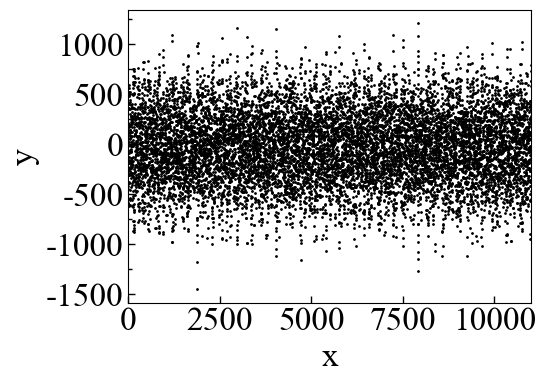

In [7]:
DataScatter_Plot(np.arange(1,11001,1), data_distance[:,3:4], y_arange=[-1500,-1000,-500,0,500,1000], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)

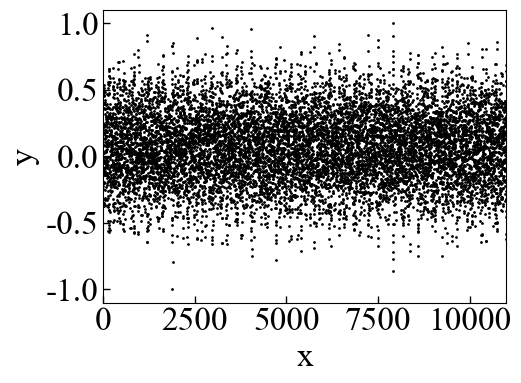

In [8]:
DataScatter_Plot(np.arange(1,11001,1), Heave, y_arange=[-1,-0.5,0,0.5,1], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)

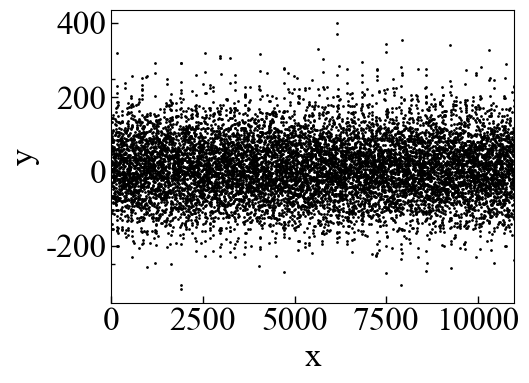

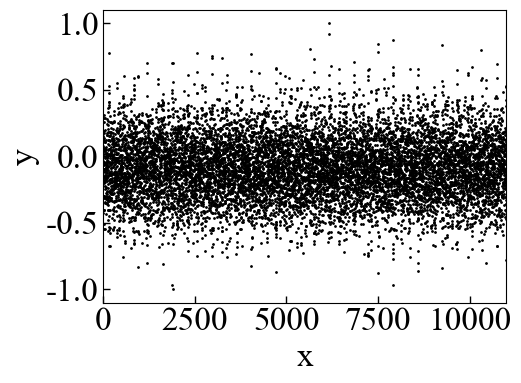

In [9]:
DataScatter_Plot(np.arange(1,11001,1), data_distance[:,1:2], y_arange=[-200,0,200,400], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)
DataScatter_Plot(np.arange(1,11001,1), Surge, y_arange=[-1,-0.5,0,0.5,1], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)

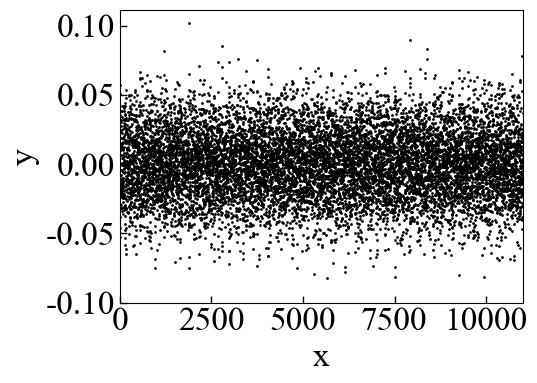

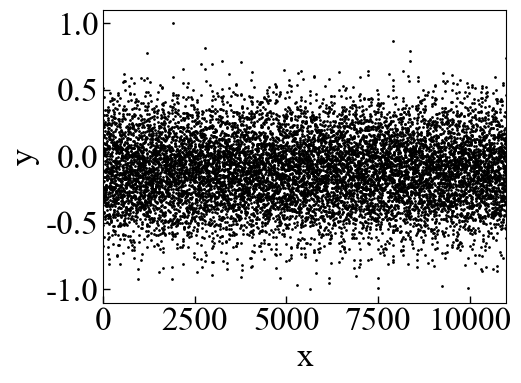

In [10]:
DataScatter_Plot(np.arange(1,11001,1), data_distance[:,5:6],  y_arange=[-0.1,-0.05,0,0.05,0.1], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)
DataScatter_Plot(np.arange(1,11001,1), Pitch, y_arange=[-1,-0.5,0,0.5,1], scatter_size=1, color="k", Inter_xaxis=2500, Inter_yaxis=250)

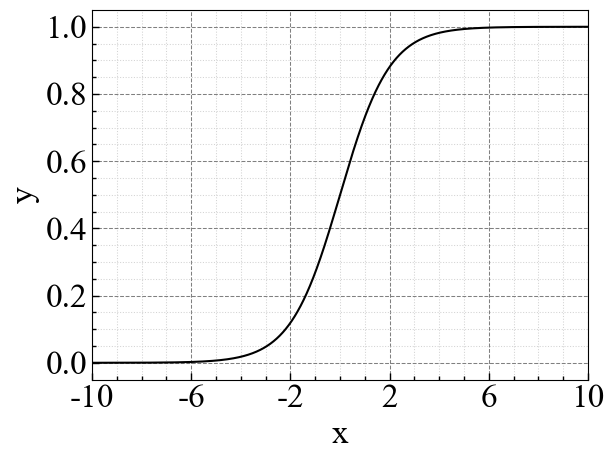

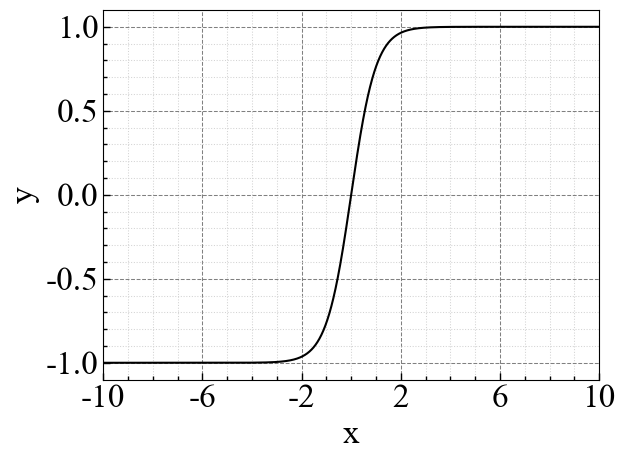

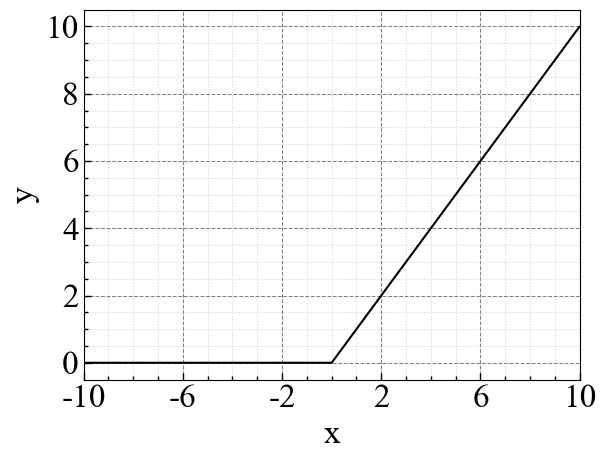

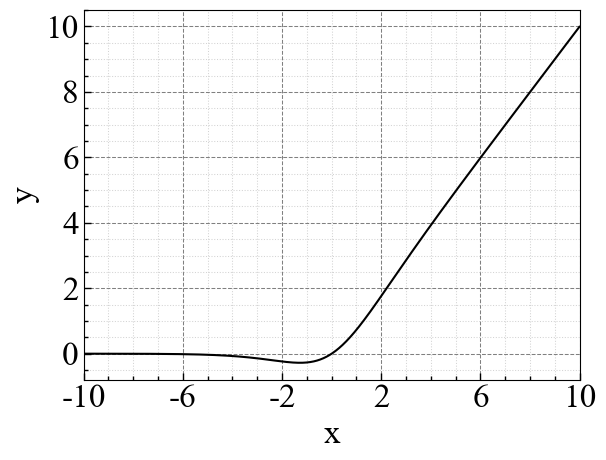

In [11]:
from matplotlib.font_manager import FontProperties
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# 定义4种常用激活函数
def sigmoid(x):
    return 1 / (1 + np.exp(-x))  # Sigmoid函数（输出范围[0,1]）

def tanh(x):
    return (np.exp(x)-np.exp(-x)) /(np.exp(x)+np.exp(-x))  # Tanh函数（输出范围[-1,1]）

def relu(x):
    return np.maximum(0, x)  # ReLU函数（负数置0，正数不变）

def swish(x,beta=1.0):
    return x*sigmoid(beta*x)  # Swish函数（x×sigmoid(x)，自门控激活）

# 激活函数可视化函数（修正字体参数）
def Function_Plot(function, a):
    x = np.arange(-10, 10, 0.01)  # 生成x轴数据（-10到10，步长0.01）
    fig = plt.figure()  # 创建画布
    # 刻度向内设置
    plt.rcParams['xtick.direction'] = 'in'  
    plt.rcParams['ytick.direction'] = 'in'  
    # 支持中文
    plt.rcParams['font.sans-serif']=['SongNTR']
    # 正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    # 调整子图间距
    fig.subplots_adjust(hspace=0.1, wspace=0.1)
    axes = plt.subplot()
    axes.minorticks_on()
    # 刻度样式设置
    axes.tick_params(axis="both", which="major", direction="in", width=1, length=5)
    axes.tick_params(axis="both", which="minor", direction="in", width=1, length=3)
    # x轴次要刻度间隔1
    axes.xaxis.set_minor_locator(MultipleLocator(1))
    # 绘制激活函数曲线（黑色）
    plt.plot(x, function(x),'black')
    
    # 定义Times New Roman字体（字号24）
    tn_font = FontProperties(family='Times New Roman', size=24)
    
    # 轴标签设置（用FontProperties指定字体）
    plt.xlabel("x", fontproperties=tn_font)
    plt.ylabel("y", fontproperties=tn_font)
    # x轴刻度（用FontProperties指定字体）
    plt.xticks([-10,-6,-2,2,6,10], fontproperties=tn_font)
    # y轴刻度（用FontProperties指定字体）
    plt.yticks(a, fontproperties=tn_font)
    
    # x轴范围
    plt.xlim(-10, 10)
    # 显示网格（主网格虚线，次网格点线）
    plt.grid(True, which="major", linestyle="--", color="gray", linewidth=0.75)
    plt.grid(True, which="minor", linestyle=":", color="lightgray", linewidth=0.75)
    # 显示图像
    plt.show()

# 调用可视化函数，绘制4种激活函数（直接运行即可）
Function_Plot(sigmoid, [0,0.2,0.4,0.6,0.8,1])  # Sigmoid的y轴刻度[0,1]
Function_Plot(tanh, [-1,-0.5,0,0.5,1])  # Tanh的y轴刻度[-1,1]
Function_Plot(relu, [0,2,4,6,8,10])  # ReLU的y轴刻度[0,10]
Function_Plot(swish, [0,2,4,6,8,10])  # Swish的y轴刻度[0,10]

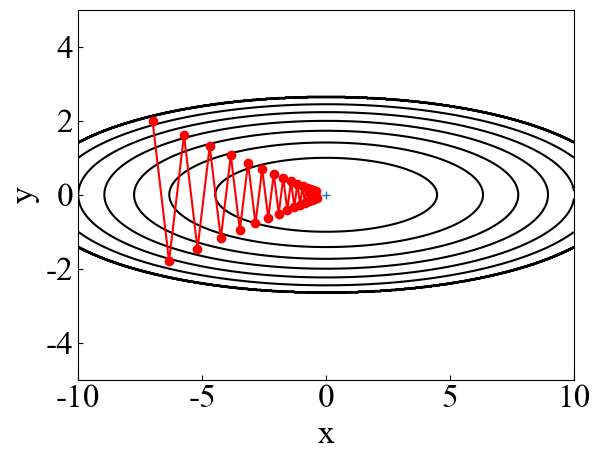

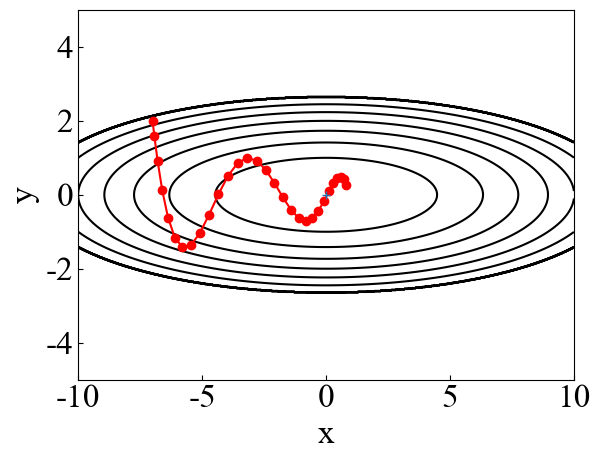

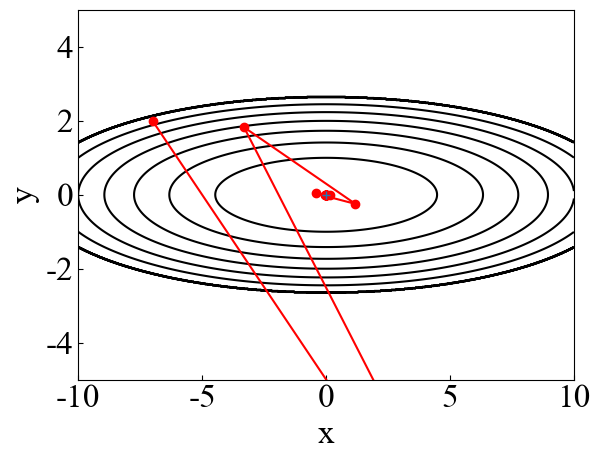

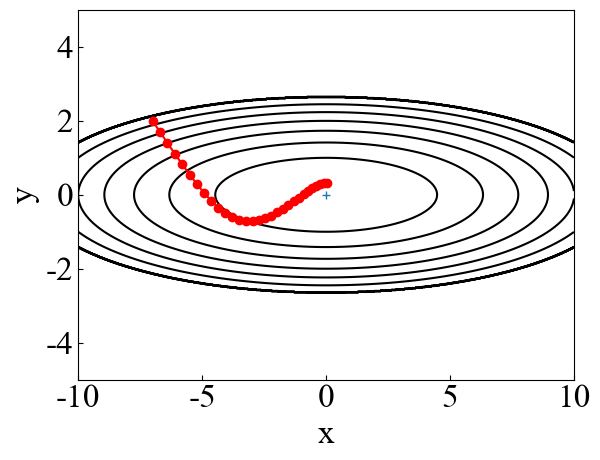

In [12]:
#比较优化器：SGD, Momentum, AdaGrad, Adam(静态图)
from matplotlib.font_manager import FontProperties
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *

# 定义目标函数（用于优化器寻优演示）
def f(x, y):
    return x**2 / 20.0 + y**2  # 椭圆型目标函数

# 目标函数的梯度（用于优化器更新）
def df(x, y):
    return x / 10.0, 2.0*y  # 对x和y的偏导数

init_pos = (-7.0, 2.0)  # 初始位置（优化起点）
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]  # 初始参数
grads = {}
grads['x'], grads['y'] = 0, 0  # 梯度初始值

# 创建优化器字典（key：优化器名称，value：优化器实例）
optimizers = OrderedDict()
optimizers["SGD"] = SGD(lr=0.95)  # SGD优化器（学习率0.95）
optimizers["Momentum"] = Momentum(lr=0.1)  # Momentum优化器（学习率0.1）
optimizers["RMSprop"] = RMSprop(lr=1.5)  # RMSprop优化器（论文中对应AdaGrad）
optimizers["Adam"] = Adam(lr=0.3)  # Adam优化器（学习率0.3）

# 定义Times New Roman字体（字号24）
tn_font = FontProperties(family='Times New Roman', size=24)

idx = 1
for key in optimizers:
    optimizer = optimizers[key]
    x_history = []  # 记录x的更新历史
    y_history = []  # 记录y的更新历史
    params['x'], params['y'] = init_pos[0], init_pos[1]  # 重置参数到初始位置
    
    for i in range(30):  # 迭代30次
        x_history.append(params['x'])  # 保存当前x
        y_history.append(params['y'])  # 保存当前y
        
        grads['x'], grads['y'] = df(params['x'], params['y'])  # 计算梯度
        optimizer.update(params, grads)  # 优化器更新参数
    
    # 生成目标函数的等高线图
    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    X, Y = np.meshgrid(x, y)  # 生成网格点
    Z = f(X, Y)  # 计算每个网格点的目标函数值
    
    # 简化等高线（Z>7的部分置0）
    mask = Z > 7
    Z[mask] = 0
    
    # 绘制等高线和优化路径
    fig = plt.figure()
    plt.rcParams['xtick.direction'] = 'in'  
    plt.rcParams['ytick.direction'] = 'in'  
    plt.rcParams['font.sans-serif']=['SimHei']
    plt.rcParams['axes.unicode_minus'] = False 
    fig.subplots_adjust(hspace=0.1, wspace=0.1)
    plt.contour(X, Y, Z, colors="black")  # 绘制等高线
    plt.plot(x_history, y_history, 'o-', color="red")  # 绘制优化路径（红点+实线）
    plt.ylim(-5, 5)  # y轴范围
    plt.xlim(-10, 10)  # x轴范围
    plt.plot(0, 0, '+')  # 绘制目标函数最小值点（原点）
    
    # 轴标签+刻度：用FontProperties指定字体
    plt.xlabel("x", fontproperties=tn_font)  # 修正：替换font参数
    plt.ylabel("y", fontproperties=tn_font)  # 修正：替换font参数
    plt.xticks(np.arange(-10, 11, 5), fontproperties=tn_font)  # 修正：替换fontproperties字符串
    plt.yticks(fontproperties=tn_font)  # 修正：添加fontproperties
    
plt.show()  # 显示4个优化器的对比图

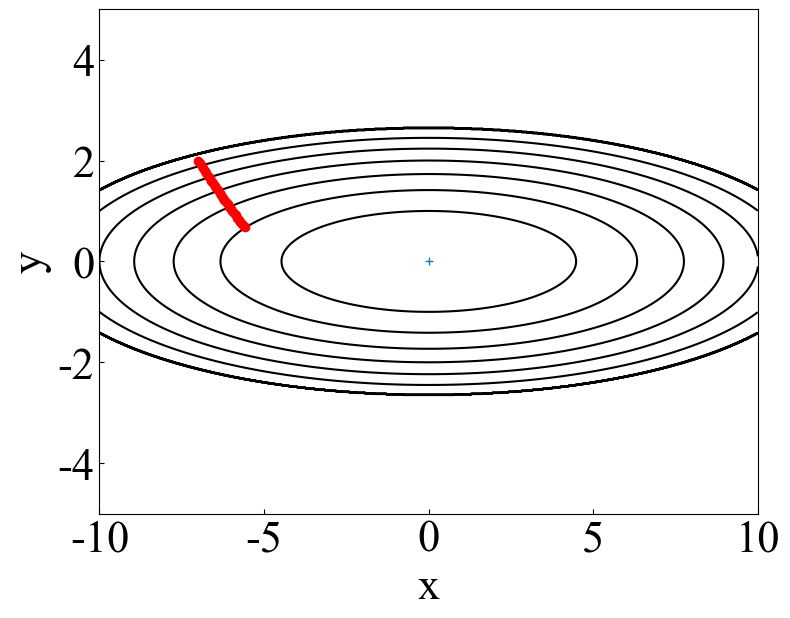

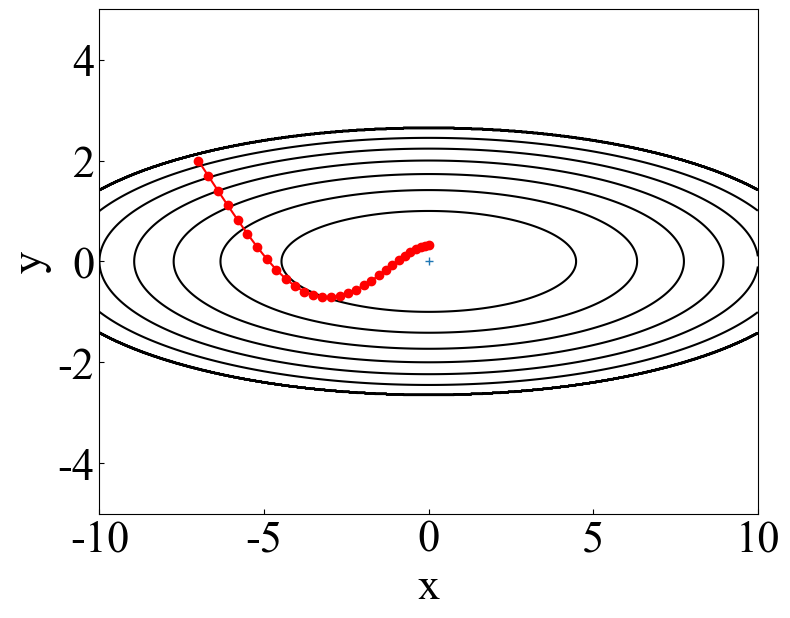

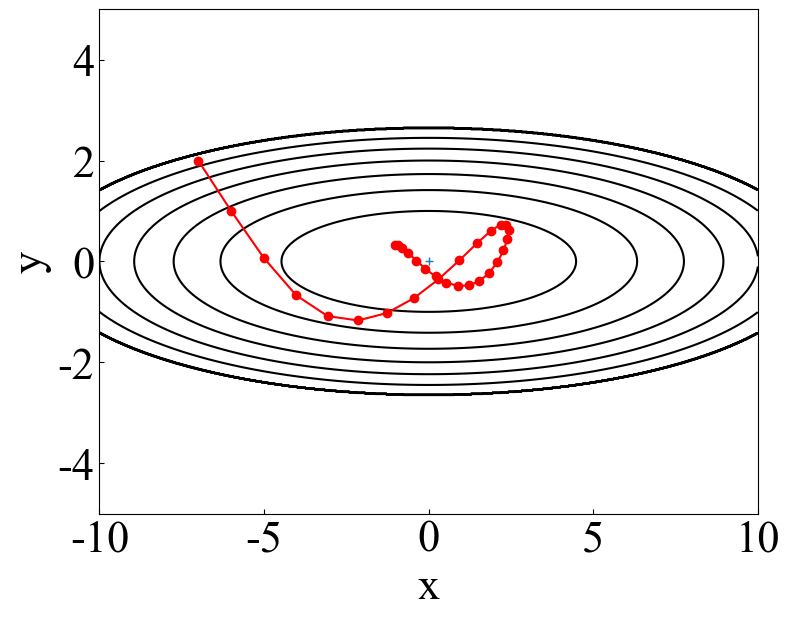

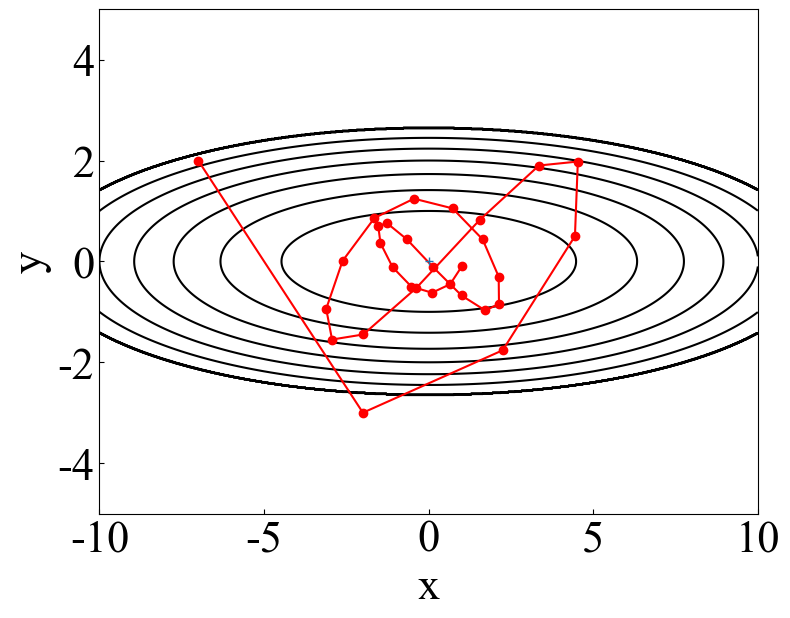

In [13]:
#比较学习率：0.08, 0.3, 1, 5(静态图)
from matplotlib.font_manager import FontProperties
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from common.optimizer import *

# 目标函数和梯度（同优化器对比部分）
def f(x, y):
    return x**2 / 20.0 + y**2

def df(x, y):
    return x / 10.0, 2.0*y

init_pos = (-7.0, 2.0)
params = {}
params['x'], params['y'] = init_pos[0], init_pos[1]
grads = {}
grads['x'], grads['y'] = 0, 0

# 创建不同学习率的Adam优化器字典
optimizers = OrderedDict()
optimizers["Adam1"] = Adam(lr=0.05)  # 学习率0.05
optimizers["Adam2"] = Adam(lr=0.3)   # 学习率0.3
optimizers["Adam3"] = Adam(lr=1)     # 学习率1
optimizers["Adam4"] = Adam(lr=5)     # 学习率5

# 定义Times New Roman字体（字号32，匹配原代码需求）
tn_font = FontProperties(family='Times New Roman', size=32)

idx = 1
for key in optimizers:
    optimizer = optimizers[key]
    x_history = []
    y_history = []
    params['x'], params['y'] = init_pos[0], init_pos[1]
    
    for i in range(30):  # 迭代30次
        x_history.append(params['x'])
        y_history.append(params['y'])
        grads['x'], grads['y'] = df(params['x'], params['y'])
        optimizer.update(params, grads)
    
    # 生成等高线图
    x = np.arange(-10, 10, 0.01)
    y = np.arange(-5, 5, 0.01)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)
    mask = Z > 7
    Z[mask] = 0
    
    # 绘制图形（画布尺寸更大，字体更大）
    fig = plt.figure(figsize=(8.5,6.55))
    plt.rcParams['xtick.direction'] = 'in'  
    plt.rcParams['ytick.direction'] = 'in'  
    plt.rcParams['font.sans-serif']=['SimHei']
    plt.rcParams['axes.unicode_minus'] = False 
    fig.subplots_adjust(hspace=0.1, wspace=0.1)
    plt.contour(X, Y, Z, colors="black")
    plt.plot(x_history, y_history, 'o-', color="red")
    plt.ylim(-5, 5)
    plt.xlim(-10, 10)
    plt.plot(0, 0, '+')
    
    # 轴标签+刻度：替换错误的font参数，用FontProperties
    plt.xlabel("x", fontproperties=tn_font)  # 修正：替换font='Times New Roman', fontsize=32
    plt.ylabel("y", fontproperties=tn_font)  # 修正：替换font='Times New Roman', fontsize=32
    plt.xticks(np.arange(-10, 11, 5), fontproperties=tn_font)  # 修正：替换fontproperties字符串+fontsize
    plt.yticks(fontproperties=tn_font)  # 修正：添加fontproperties

plt.show()

#### 时序模型A

In [14]:
# GRU
def Model_GRU(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(GRU(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(GRU(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# LSTM
def Model_LSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh', return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh'))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

# BiLSTM
from keras.layers import LeakyReLU
def Model_BiLSTM(train_X, train_Y, valid_X, valid_Y, lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(Bidirectional(LSTM(25, batch_input_shape=(24, train_X.shape[1], train_X.shape[2]),stateful=False), merge_mode='concat'))  #25×5的数据输入
    model.add(LeakyReLU(alpha=0.3))
    model.add(Dense(train_Y.shape[1])) 
    model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

def series_to_supervised(data, n_in, n_out, dropnan=True):
#      '''
#      说明：将每一个特征（输入+输出）的单步-目标步长数全数列举出来
#      '''
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    agg = concat(cols, axis=1)
    agg.columns = names
    if dropnan:
        agg.dropna(inplace=True)
    return agg
def deal_data1(data, features_number, time_steps):
    '''
    适用：单/多特征，单/多预测步长
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+输出+所需预测步长的输出（当为单特征时，输入、输出为同一列）
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def deal_data2(data, features_number, time_steps):
    '''
    适用：多特征，单/多预测步长，不适用于单特征
    data：数据集（仅包括输入+输出，且输出仅有一列并在最后）
    feature_number：输入+输出变量数
    n_in：预测步长
    结果解释：输入+所需预测步长的输出
    '''
    process_data = series_to_supervised(data, time_steps, 1, dropnan=True)
    a = []
    for i in range(features_number-1, features_number*(time_steps+1)-1):
        a.append(i)
        i = i+1
    process_data.drop(process_data.columns[a], axis=1, inplace=True)
    return process_data.values
def split_sequence(dataset, n_past):
    x, y = list(), list()
    for i in range(len(dataset)):
        end_ix = i + n_past
        if end_ix > len(dataset):
            break
        seq_x, seq_y = dataset[i:end_ix, :-1], dataset[i, -1]
        x.append(seq_x)
        y.append(seq_y)
    return np.array(x), np.array(y)
def split_train_valid(data_X, data_Y, n_train_times, n_valid_times):
    '''
    说明：将数据集划分为训练集和验证集
    疑问：先数据切割重组再划分数据集，先划分数据集再数据切割重组，有何区别影响？
    '''
    train_x, valid_x = data_X[:n_train_times, :, :], data_X[n_train_times:n_valid_times, :, :]
    train_y, valid_y = data_Y[:n_train_times], data_Y[n_train_times:n_valid_times]
    train_y = train_y.reshape((n_train_times, 1))
    valid_y = valid_y.reshape((n_valid_times-n_train_times, 1))
    return train_x, train_y, valid_x, valid_y
def loss_plot(history, epo, length, width):
    # plot history
    plt.figure(figsize = (length, width))
    # 将x周的刻度线方向设置向内
    plt.rcParams['xtick.direction'] = 'in'  
    # 将y轴的刻度方向设置向内
    plt.rcParams['ytick.direction'] = 'in'  
    #设置字体以便支持中文
    plt.rcParams['font.sans-serif']=['SimHei']
    #为正常显示负号
    plt.rcParams['axes.unicode_minus'] = False 
    plt.plot(history.history['loss'], label = 'train loss')
    plt.plot(history.history['val_loss'], label = 'valid loss')
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.show()
    print(np.hstack((np.array(history.history['loss']).reshape(epo,1), np.array(history.history['val_loss']).reshape(epo,1))))

from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
def evaluate(valid_y,pre_Y):
    XP1 = valid_y.copy()  # 真实值
    XA1 = pre_Y.copy()   # 预测值
    c1 =abs((XP1-XA1))  # 绝对误差
    MAE1 = (c1.sum())/(c1.shape[0])  # 手动计算MAE
    print('MAE:',MAE1)
    print('MAE(sklearn):', mean_absolute_error(XP1, XA1))  # sklearn计算MAE
    
    # 手动计算MAPE（替代原来的mean_absolute_percentage_error）
    # 公式：MAPE = (1/n) * sum(|(真实值-预测值)/真实值|) * 100%
    MAPE = (np.mean(np.abs((XP1 - XA1) / XP1))) * 100
    print('MAPE:', MAPE)
    
    # 计算MSE
    r1 = ((XP1-XA1)*(XP1-XA1)).sum()/(XP1.shape[0])  # 手动计算MSE
    MSE1 = r1
    print('MSE:', MSE1)
    print('MSE(sklearn):', mean_squared_error(XP1, XA1))  # sklearn计算MSE
    print('RMSE(sklearn):',np.sqrt(mean_squared_error(XP1, XA1)))  # RMSE
    # 计算Accuracy（自定义指标）
    real1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)  # 真实值积分
    pre1 = np.trapz(abs((XA1 - (XP1.sum()/(XP1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)  # 预测值积分
    Acc1 = 1 - abs(1 - (pre1/real1))  # 计算Acc
    print('Acc:', Acc1)
    
def FanGuiHua_surge(valid_sur_y,sur_pre_Y):
    fan_surge_real=Surge_scaler.inverse_transform(valid_sur_y)
    fan_surge_pre=Surge_scaler.inverse_transform(sur_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_surge_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_surge_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_surge_real,fan_surge_pre)
    return fan_surge_real,fan_surge_pre
def FanGuiHua_pitch(valid_pit_y,pit_pre_Y):
    fan_pitch_real=Pitch_scaler.inverse_transform(valid_pit_y)
    fan_pitch_pre=Pitch_scaler.inverse_transform(pit_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_pitch_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_pitch_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_pitch_real,fan_pitch_pre)
    return fan_pitch_real,fan_pitch_pre
def FanGuiHua_sway(valid_sway_y,sway_pre_Y):
    fan_sway_real=Sway_scaler.inverse_transform(valid_sway_y)
    fan_sway_pre=Sway_scaler.inverse_transform(sway_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_sway_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_sway_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_sway_real,fan_sway_pre)
    return fan_sway_real,fan_sway_pre
def FanGuiHua_roll(valid_roll_y,roll_pre_Y):
    fan_roll_real=Roll_scaler.inverse_transform(valid_roll_y)
    fan_roll_pre=Roll_scaler.inverse_transform(roll_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_roll_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_roll_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_roll_real,fan_roll_pre)
    return fan_roll_real,fan_roll_pre
def FanGuiHua_yaw(valid_yaw_y,yaw_pre_Y):
    fan_yaw_real=Yaw_scaler.inverse_transform(valid_yaw_y)
    fan_yaw_pre=Yaw_scaler.inverse_transform(yaw_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_yaw_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_yaw_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_yaw_real,fan_yaw_pre)
    return fan_yaw_real,fan_yaw_pre
def FanGuiHua_heave(valid_hea_y,hea_pre_Y):
    fan_heave_real=Heave_scaler.inverse_transform(valid_hea_y)
    fan_heave_pre=Heave_scaler.inverse_transform(hea_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_heave_real[:200],color='blue',label='real')   #真实曲线
    plt.plot(fan_heave_pre[:200],color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_heave_real,fan_heave_pre)
    return fan_heave_real,fan_heave_pre
def FanGuiHua_force(valid_for_y,for_pre_Y):
    fan_force_real=Force1_scaler.inverse_transform(valid_for_y)
    fan_force_pre=Force1_scaler.inverse_transform(for_pre_Y)
    plt.figure(figsize=(30,4), dpi=100)
    plt.plot(fan_force_real,color='blue',label='real')   #真实曲线
    plt.plot(fan_force_pre,color='orange',label='prediction') #预测曲线
    plt.legend()
    plt.show()
    evaluate(fan_force_real,fan_force_pre)
    return fan_force_real,fan_force_pre

# def train_1(H,Motion):
#     Motion_scaled1 = deal_data2(np.hstack((H,Motion))[345:,:], 2, 55)
#     Motion_x1,Motion_y1 = split_sequence(Motion_scaled1, 55)

#     train_Motion_x1, train_Motion_y1, valid_Motion_x1, valid_Motion_y1 = split_train_valid(Motion_x1,Motion_y1, 7500, 10500)
#     Motion1_model1, Motion1_history1, Motion1_pre_Y1 = Model_LSTM(train_Motion_x1, train_Motion_y1, valid_Motion_x1, valid_Motion_y1, lr=0.01, epochs=epo, batch_size=50)
#     return

(10546, 55, 1)
Epoch 1/60
150/150 - 2s - loss: 0.0420 - val_loss: 0.0206
Epoch 2/60
150/150 - 2s - loss: 0.0161 - val_loss: 0.0087
Epoch 3/60
150/150 - 2s - loss: 0.0113 - val_loss: 0.0073
Epoch 4/60
150/150 - 2s - loss: 0.0097 - val_loss: 0.0060
Epoch 5/60
150/150 - 2s - loss: 0.0088 - val_loss: 0.0056
Epoch 6/60
150/150 - 2s - loss: 0.0080 - val_loss: 0.0047
Epoch 7/60
150/150 - 2s - loss: 0.0072 - val_loss: 0.0041
Epoch 8/60
150/150 - 2s - loss: 0.0067 - val_loss: 0.0041
Epoch 9/60
150/150 - 2s - loss: 0.0067 - val_loss: 0.0045
Epoch 10/60
150/150 - 2s - loss: 0.0065 - val_loss: 0.0042
Epoch 11/60
150/150 - 2s - loss: 0.0062 - val_loss: 0.0038
Epoch 12/60
150/150 - 2s - loss: 0.0060 - val_loss: 0.0038
Epoch 13/60
150/150 - 2s - loss: 0.0060 - val_loss: 0.0036
Epoch 14/60
150/150 - 2s - loss: 0.0059 - val_loss: 0.0042
Epoch 15/60
150/150 - 2s - loss: 0.0060 - val_loss: 0.0040
Epoch 16/60
150/150 - 2s - loss: 0.0060 - val_loss: 0.0036
Epoch 17/60
150/150 - 2s - loss: 0.0055 - val_loss

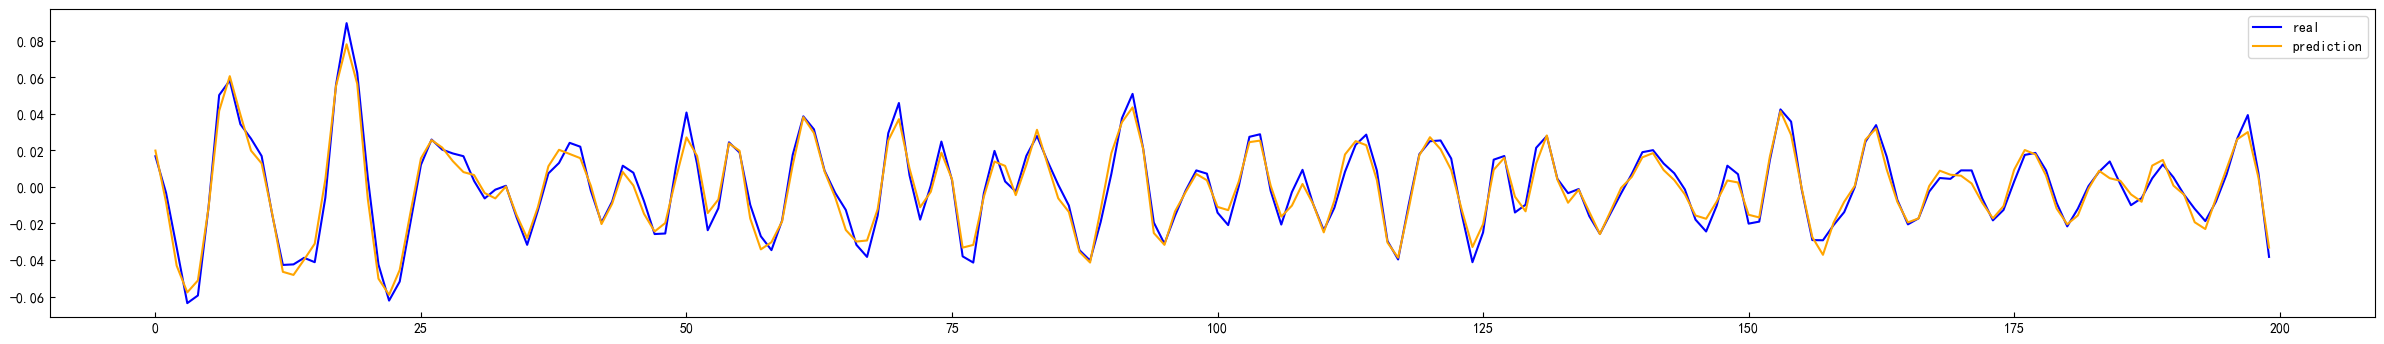

MAE: 0.004131641190726496
MAE(sklearn): 0.004131641190726496
MAPE: 81.30688259910734
MSE: 2.656598138262084e-05
MSE(sklearn): 2.656598138262084e-05
RMSE(sklearn): 0.00515421976468028
Acc: 0.9410323494788465


In [ ]:
# 输出1步长pitch
pitch_scaled1 = deal_data2(np.hstack((H,Pitch))[345:,:], 2, 55)
pitch_x1,pitch_y1 = split_sequence(pitch_scaled1, 55)
print(pitch_x1.shape)

train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1 = split_train_valid(pitch_x1,pitch_y1, 7500, 10500)
pit1_model1, pit1_history1, pit1_pre_Y1 = Model_LSTM(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, lr=0.01, epochs=60, batch_size=50)

fan1_pitch_real1,fan1_pitch_pre1 = FanGuiHua_pitch(valid_pit_y1,pit1_pre_Y1)


In [16]:
print(np.hstack((fan1_pitch_real1,fan1_pitch_pre1)))

[[ 0.0168      0.0198684 ]
 [-0.00323    -0.00837497]
 [-0.0331     -0.04307327]
 ...
 [ 0.0254      0.02465191]
 [ 0.0245      0.02483131]
 [ 0.0143      0.01188718]]


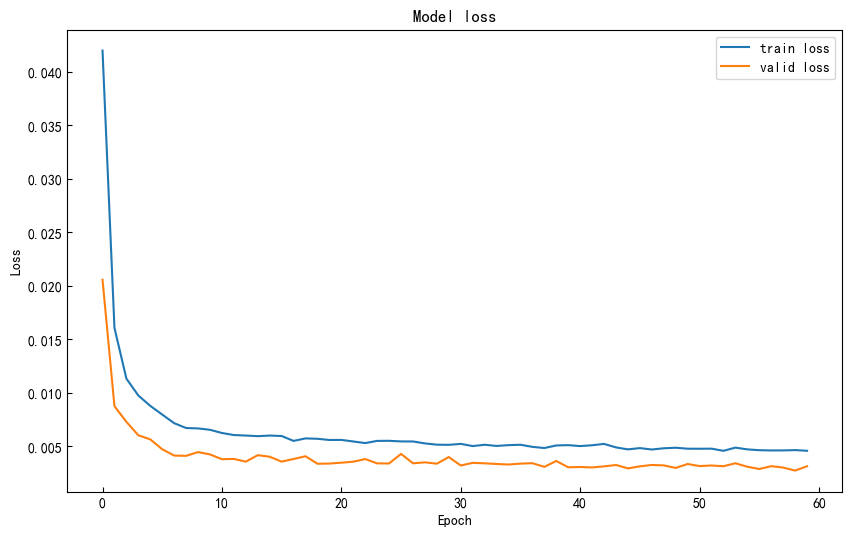

[[0.04197175 0.02055608]
 [0.01605529 0.00874458]
 [0.01131717 0.00727455]
 [0.00973618 0.00601949]
 [0.00876928 0.00563791]
 [0.00795585 0.00471341]
 [0.00715238 0.00412655]
 [0.00670006 0.00409824]
 [0.0066614  0.00445349]
 [0.00653433 0.00423157]
 [0.00623485 0.00378542]
 [0.00604209 0.00381076]
 [0.00599496 0.00355815]
 [0.00593769 0.00416218]
 [0.00599497 0.00401651]
 [0.00595309 0.00355916]
 [0.00549508 0.003806  ]
 [0.00573016 0.00406062]
 [0.00569364 0.00336033]
 [0.00558144 0.00337866]
 [0.00558773 0.0034578 ]
 [0.00544134 0.00355244]
 [0.00529279 0.00379981]
 [0.00549651 0.00339546]
 [0.00550397 0.00338628]
 [0.00544746 0.00428047]
 [0.00544194 0.00340193]
 [0.00526148 0.00348995]
 [0.00514398 0.00336809]
 [0.00512795 0.00398793]
 [0.00521788 0.00319484]
 [0.00501143 0.00344414]
 [0.00513507 0.00340158]
 [0.00502291 0.00333793]
 [0.00509945 0.00328857]
 [0.00513535 0.00337309]
 [0.00493953 0.00341249]
 [0.00482966 0.00307026]
 [0.00507034 0.00362011]
 [0.00509877 0.00302707]


In [17]:
np.savetxt('pitch_步长1(3.2.2).csv',np.hstack((fan1_pitch_real1,fan1_pitch_pre1)),delimiter=',')
loss_plot(pit1_history1, epo=60, length=10, width=6)

(10546, 55, 1)
Epoch 1/60
150/150 - 2s - loss: 0.0305 - val_loss: 0.0227
Epoch 2/60
150/150 - 2s - loss: 0.0239 - val_loss: 0.0224
Epoch 3/60
150/150 - 2s - loss: 0.0234 - val_loss: 0.0225
Epoch 4/60
150/150 - 2s - loss: 0.0229 - val_loss: 0.0213
Epoch 5/60
150/150 - 2s - loss: 0.0221 - val_loss: 0.0202
Epoch 6/60
150/150 - 2s - loss: 0.0215 - val_loss: 0.0201
Epoch 7/60
150/150 - 2s - loss: 0.0212 - val_loss: 0.0200
Epoch 8/60
150/150 - 2s - loss: 0.0211 - val_loss: 0.0198
Epoch 9/60
150/150 - 2s - loss: 0.0210 - val_loss: 0.0202
Epoch 10/60
150/150 - 2s - loss: 0.0208 - val_loss: 0.0196
Epoch 11/60
150/150 - 2s - loss: 0.0207 - val_loss: 0.0196
Epoch 12/60
150/150 - 2s - loss: 0.0206 - val_loss: 0.0194
Epoch 13/60
150/150 - 2s - loss: 0.0207 - val_loss: 0.0191
Epoch 14/60
150/150 - 2s - loss: 0.0203 - val_loss: 0.0190
Epoch 15/60
150/150 - 2s - loss: 0.0199 - val_loss: 0.0187
Epoch 16/60
150/150 - 2s - loss: 0.0195 - val_loss: 0.0176
Epoch 17/60
150/150 - 2s - loss: 0.0189 - val_loss

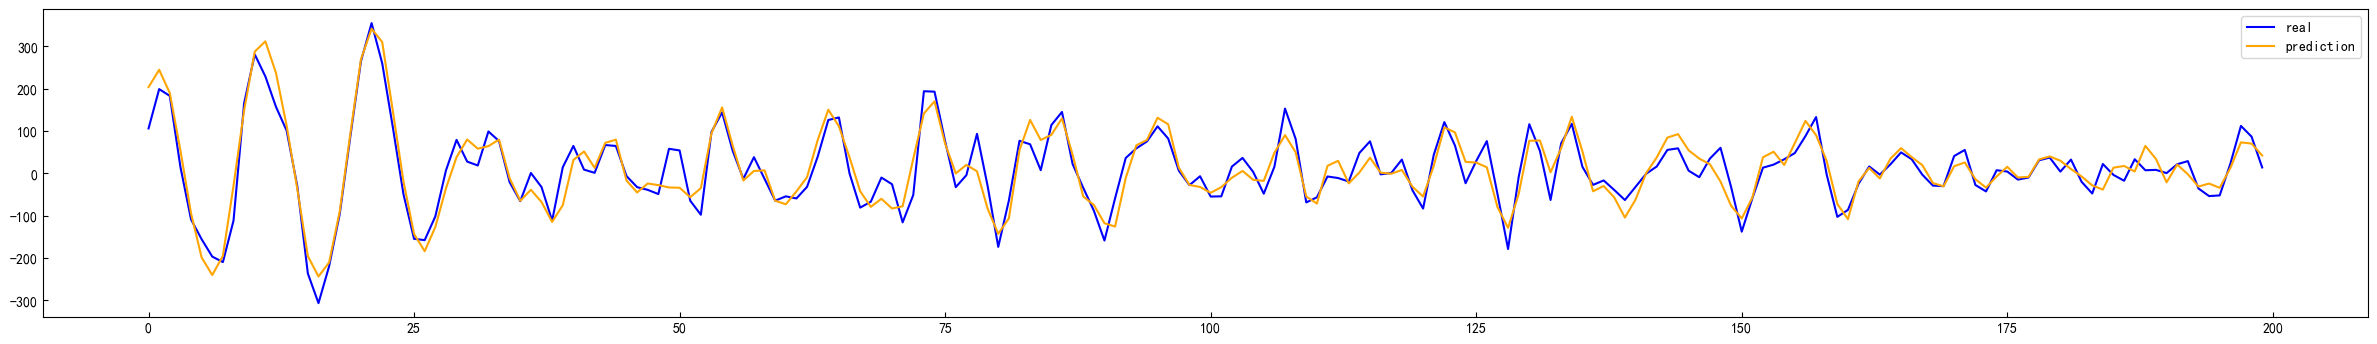

MAE: 28.796636582749148
MAE(sklearn): 28.796636582749148
MAPE: 323.2453227586511
MSE: 1315.1653610067485
MSE(sklearn): 1315.1653610067485
RMSE(sklearn): 36.265208685553546
Acc: 0.9521588748478662


In [18]:
# 输出1步长surge
surge_scaled1 = deal_data2(np.hstack((H,Surge))[345:,:], 2, 55)
surge_x1,surge_y1 = split_sequence(surge_scaled1, 55)
print(surge_x1.shape)

train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1 = split_train_valid(surge_x1,surge_y1, 7500, 10500)
sur1_model1, sur1_history1, sur1_pre_Y1 = Model_LSTM(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, lr=0.01, epochs=60, batch_size=50)

fan1_surge_real1,fan1_surge_pre1 = FanGuiHua_surge(valid_sur_y1,sur1_pre_Y1)

In [19]:
print(np.hstack((fan1_surge_real1,fan1_surge_pre1)))

[[106.         203.8125    ]
 [199.         244.6648407 ]
 [183.         189.82575989]
 ...
 [-67.7        -85.02935791]
 [ 17.2         30.17133904]
 [ 75.6         81.12863159]]


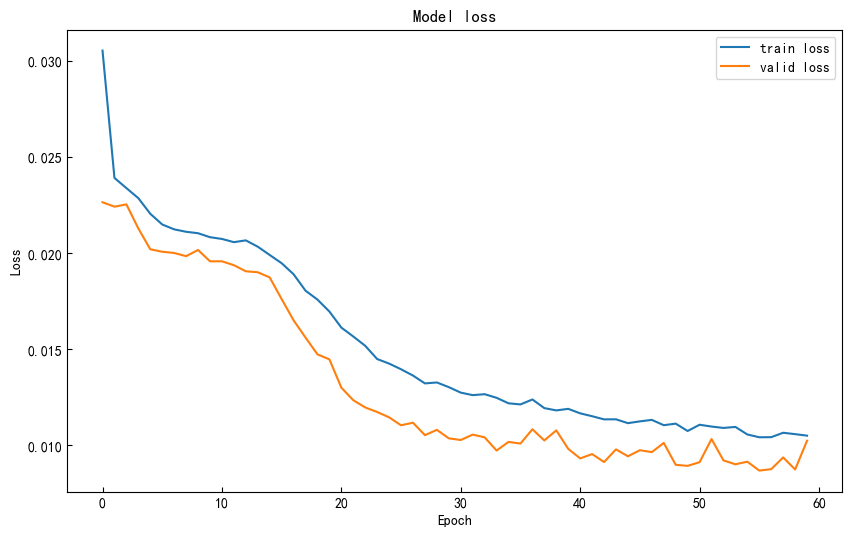

[[0.03054896 0.02265131]
 [0.02391703 0.02242097]
 [0.02338769 0.02254097]
 [0.02286333 0.02128724]
 [0.0220511  0.02020191]
 [0.02149319 0.02007364]
 [0.02123998 0.02001023]
 [0.0211136  0.01984199]
 [0.02103791 0.02016576]
 [0.02083175 0.01957601]
 [0.0207401  0.01957592]
 [0.02057274 0.01937345]
 [0.02066609 0.0190563 ]
 [0.02033668 0.01900601]
 [0.01990541 0.01873671]
 [0.01947646 0.0176093 ]
 [0.01890173 0.01650378]
 [0.01804565 0.01560558]
 [0.01758225 0.01473044]
 [0.01695888 0.01446859]
 [0.01612357 0.01299754]
 [0.01566003 0.01234248]
 [0.01517522 0.01196528]
 [0.01448653 0.0117283 ]
 [0.01424881 0.01145028]
 [0.01395389 0.01103697]
 [0.01362567 0.01117051]
 [0.01321799 0.01052132]
 [0.01326626 0.01079941]
 [0.01302235 0.01035606]
 [0.01273758 0.01026991]
 [0.01260659 0.01055055]
 [0.01265591 0.01040944]
 [0.01246745 0.00972122]
 [0.01218136 0.01017105]
 [0.01212331 0.01008444]
 [0.01238028 0.01082954]
 [0.01193027 0.01024697]
 [0.01181204 0.01077291]
 [0.01189246 0.00980927]


In [20]:
np.savetxt('surge_步长1(3.2.2).csv',np.hstack((fan1_surge_real1,fan1_surge_pre1)),delimiter=',')
loss_plot(sur1_history1, epo=60, length=10, width=6)

(10546, 55, 1)
Epoch 1/60
150/150 - 2s - loss: 0.0230 - val_loss: 0.0084
Epoch 2/60
150/150 - 2s - loss: 0.0089 - val_loss: 0.0060
Epoch 3/60
150/150 - 2s - loss: 0.0077 - val_loss: 0.0037
Epoch 4/60
150/150 - 2s - loss: 0.0060 - val_loss: 0.0055
Epoch 5/60
150/150 - 2s - loss: 0.0053 - val_loss: 0.0041
Epoch 6/60
150/150 - 2s - loss: 0.0049 - val_loss: 0.0037
Epoch 7/60
150/150 - 2s - loss: 0.0046 - val_loss: 0.0026
Epoch 8/60
150/150 - 2s - loss: 0.0040 - val_loss: 0.0022
Epoch 9/60
150/150 - 2s - loss: 0.0036 - val_loss: 0.0022
Epoch 10/60
150/150 - 2s - loss: 0.0032 - val_loss: 0.0022
Epoch 11/60
150/150 - 2s - loss: 0.0031 - val_loss: 0.0019
Epoch 12/60
150/150 - 2s - loss: 0.0030 - val_loss: 0.0017
Epoch 13/60
150/150 - 2s - loss: 0.0031 - val_loss: 0.0021
Epoch 14/60
150/150 - 2s - loss: 0.0030 - val_loss: 0.0020
Epoch 15/60
150/150 - 2s - loss: 0.0029 - val_loss: 0.0024
Epoch 16/60
150/150 - 2s - loss: 0.0031 - val_loss: 0.0017
Epoch 17/60
150/150 - 2s - loss: 0.0029 - val_loss

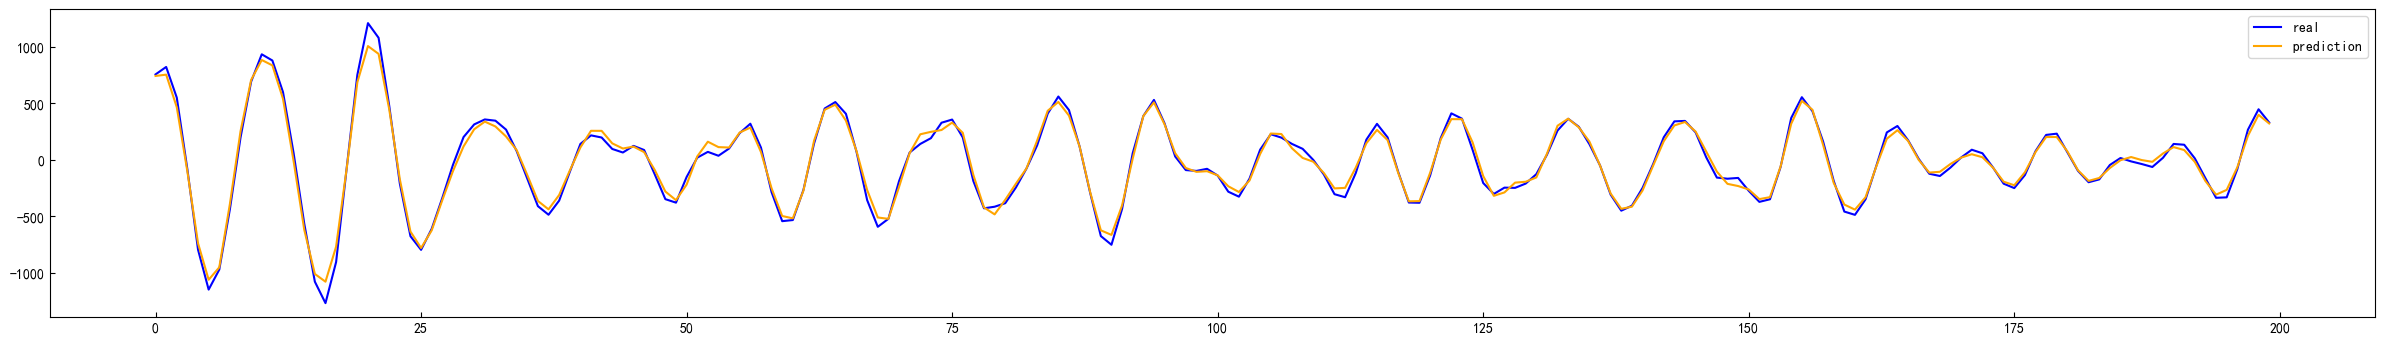

MAE: 34.24790259525226
MAE(sklearn): 34.24790259525226
MAPE: 81.91723827553969
MSE: 1895.33111746102
MSE(sklearn): 1895.33111746102
RMSE(sklearn): 43.5354007384912
Acc: 0.9530484199101678


In [21]:
# 输出1步长heave
heave_scaled1 = deal_data2(np.hstack((H,Heave))[345:,:], 2, 55)
heave_x1,heave_y1 = split_sequence(heave_scaled1, 55)
print(heave_x1.shape)

train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1 = split_train_valid(heave_x1,heave_y1, 7500, 10500)
hea1_model1, hea1_history1, hea1_pre_Y1 = Model_LSTM(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, lr=0.01, epochs=60, batch_size=50)

fan1_heave_real1,fan1_heave_pre1 = FanGuiHua_heave(valid_hea_y1,hea1_pre_Y1)

In [22]:
print(np.hstack((fan1_heave_real1,fan1_heave_pre1)))

[[ 756.          742.23724365]
 [ 822.          753.73522949]
 [ 550.          465.24484253]
 ...
 [-226.         -226.39154053]
 [  81.2          77.60266113]
 [ 338.          325.64788818]]


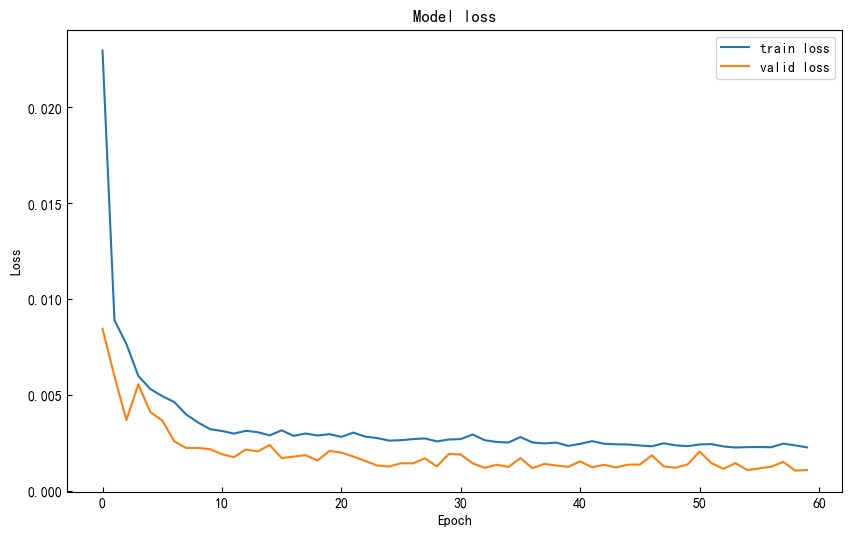

[[0.02296655 0.00844717]
 [0.00889288 0.00596792]
 [0.00765123 0.00368172]
 [0.00598364 0.00554866]
 [0.00530682 0.00410184]
 [0.00492985 0.00365958]
 [0.00462725 0.00257535]
 [0.00397676 0.0022243 ]
 [0.00355546 0.00222796]
 [0.00320734 0.00216282]
 [0.00311195 0.00190087]
 [0.00297339 0.0017454 ]
 [0.00311986 0.00214148]
 [0.00304795 0.00204359]
 [0.00288199 0.00238078]
 [0.0031477  0.00169861]
 [0.00285577 0.00177342]
 [0.0029789  0.00184929]
 [0.00287574 0.00157113]
 [0.00294684 0.0020706 ]
 [0.00280401 0.0019816 ]
 [0.0030268  0.00178014]
 [0.0028167  0.00154737]
 [0.00274138 0.0013116 ]
 [0.00260971 0.00125863]
 [0.00263048 0.00142845]
 [0.0026877  0.00142289]
 [0.00272297 0.00168442]
 [0.0025684  0.00126194]
 [0.00266683 0.00191114]
 [0.00268926 0.00188342]
 [0.00292876 0.00142327]
 [0.00262871 0.00118791]
 [0.00253933 0.00134963]
 [0.00251161 0.00123814]
 [0.00279719 0.00169651]
 [0.00251217 0.00116976]
 [0.00246182 0.00139459]
 [0.0025056  0.00130969]
 [0.00233311 0.00124224]


In [23]:
np.savetxt('heave_步长1(3.2.2).csv',np.hstack((fan1_heave_real1,fan1_heave_pre1)),delimiter=',')
loss_plot(hea1_history1, epo=60, length=10, width=6)

In [25]:
# 不同激活函数下的H-Heave预测
# LSTM
def Model_LSTM_Activation(train_X, train_Y, valid_X, valid_Y, activation='tanh', lr=0.01, epochs=20, batch_size=256):
    model = Sequential()
    model.add(LSTM(25, activation='tanh', recurrent_activation='sigmoid', dropout=0.0, return_sequences=True, input_shape=(train_X.shape[1], train_X.shape[2])))  #25×5的数据输入
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh',recurrent_activation='sigmoid',dropout=0.0,recurrent_dropout=0.0, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(100, activation='tanh',recurrent_activation='sigmoid',dropout=0.0,recurrent_dropout=0.0))
    model.add(Dropout(0.3))
    model.add(Dense(train_Y.shape[1])) 
#     model.add(Activation('tanh'))
    adam = Adam(lr = lr)
    model.compile(loss='mse', optimizer='adam')
    history = model.fit(train_X, train_Y, epochs=epochs, batch_size=batch_size, validation_data=(valid_X, valid_Y), verbose=2, shuffle=False)
    model_structure = model.summary()
    pre_Y = model.predict(valid_X)
    return model, history, pre_Y

model_sigmoid, history_sigmoid, pre_Y_sigmoid = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='sigmoid', lr=0.01, epochs=60, batch_size=256)
model_tanh, history_tanh, pre_Y_tanh = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.01, epochs=60, batch_size=256)
model_relu, history_relu, pre_Y_relu = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='relu', lr=0.01, epochs=60, batch_size=256)
model_swish, history_swish, pre_Y_swish = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='swish', lr=0.01, epochs=60, batch_size=256)


Epoch 1/60
30/30 - 1s - loss: 0.0547 - val_loss: 0.0183
Epoch 2/60
30/30 - 1s - loss: 0.0157 - val_loss: 0.0105
Epoch 3/60
30/30 - 0s - loss: 0.0117 - val_loss: 0.0089
Epoch 4/60
30/30 - 0s - loss: 0.0100 - val_loss: 0.0073
Epoch 5/60
30/30 - 0s - loss: 0.0090 - val_loss: 0.0069
Epoch 6/60
30/30 - 0s - loss: 0.0082 - val_loss: 0.0063
Epoch 7/60
30/30 - 0s - loss: 0.0077 - val_loss: 0.0049
Epoch 8/60
30/30 - 0s - loss: 0.0067 - val_loss: 0.0053
Epoch 9/60
30/30 - 0s - loss: 0.0082 - val_loss: 0.0041
Epoch 10/60
30/30 - 0s - loss: 0.0059 - val_loss: 0.0036
Epoch 11/60
30/30 - 0s - loss: 0.0056 - val_loss: 0.0033
Epoch 12/60
30/30 - 0s - loss: 0.0053 - val_loss: 0.0031
Epoch 13/60
30/30 - 0s - loss: 0.0050 - val_loss: 0.0029
Epoch 14/60
30/30 - 0s - loss: 0.0048 - val_loss: 0.0027
Epoch 15/60
30/30 - 0s - loss: 0.0046 - val_loss: 0.0027
Epoch 16/60
30/30 - 0s - loss: 0.0045 - val_loss: 0.0024
Epoch 17/60
30/30 - 0s - loss: 0.0044 - val_loss: 0.0030
Epoch 18/60
30/30 - 0s - loss: 0.0042 - 

In [26]:
# 不同激活函数下的H-Surge预测
model_sigmoid2, history_sigmoid2, pre_Y_sigmoid2 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='sigmoid', lr=0.01, epochs=60, batch_size=256)
model_tanh2, history_tanh2, pre_Y_tanh2 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.01, epochs=60, batch_size=256)
model_relu2, history_relu2, pre_Y_relu2 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='relu', lr=0.01, epochs=60, batch_size=256)
model_swish2, history_swish2, pre_Y_swish2 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='swish', lr=0.01, epochs=60, batch_size=256)

Epoch 1/60
30/30 - 1s - loss: 0.0474 - val_loss: 0.0285
Epoch 2/60
30/30 - 1s - loss: 0.0255 - val_loss: 0.0226
Epoch 3/60
30/30 - 0s - loss: 0.0240 - val_loss: 0.0225
Epoch 4/60
30/30 - 0s - loss: 0.0237 - val_loss: 0.0223
Epoch 5/60
30/30 - 0s - loss: 0.0235 - val_loss: 0.0222
Epoch 6/60
30/30 - 0s - loss: 0.0232 - val_loss: 0.0220
Epoch 7/60
30/30 - 0s - loss: 0.0231 - val_loss: 0.0221
Epoch 8/60
30/30 - 0s - loss: 0.0228 - val_loss: 0.0218
Epoch 9/60
30/30 - 0s - loss: 0.0226 - val_loss: 0.0214
Epoch 10/60
30/30 - 0s - loss: 0.0224 - val_loss: 0.0212
Epoch 11/60
30/30 - 0s - loss: 0.0223 - val_loss: 0.0209
Epoch 12/60
30/30 - 0s - loss: 0.0217 - val_loss: 0.0202
Epoch 13/60
30/30 - 0s - loss: 0.0213 - val_loss: 0.0201
Epoch 14/60
30/30 - 0s - loss: 0.0210 - val_loss: 0.0200
Epoch 15/60
30/30 - 0s - loss: 0.0210 - val_loss: 0.0199
Epoch 16/60
30/30 - 0s - loss: 0.0209 - val_loss: 0.0198
Epoch 17/60
30/30 - 0s - loss: 0.0208 - val_loss: 0.0197
Epoch 18/60
30/30 - 0s - loss: 0.0207 - 

In [27]:
# 不同激活函数下的H-Pitch预测
model_sigmoid3, history_sigmoid3, pre_Y_sigmoid3 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='sigmoid', lr=0.01, epochs=60, batch_size=256)
model_tanh3, history_tanh3, pre_Y_tanh3 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.01, epochs=60, batch_size=256)
model_relu3, history_relu3, pre_Y_relu3 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='relu', lr=0.01, epochs=60, batch_size=256)
model_swish3, history_swish3, pre_Y_swish3 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='swish', lr=0.01, epochs=60, batch_size=256)

Epoch 1/60
30/30 - 1s - loss: 0.0682 - val_loss: 0.0636
Epoch 2/60
30/30 - 0s - loss: 0.0472 - val_loss: 0.0350
Epoch 3/60
30/30 - 0s - loss: 0.0308 - val_loss: 0.0250
Epoch 4/60
30/30 - 0s - loss: 0.0230 - val_loss: 0.0176
Epoch 5/60
30/30 - 0s - loss: 0.0171 - val_loss: 0.0112
Epoch 6/60
30/30 - 0s - loss: 0.0132 - val_loss: 0.0088
Epoch 7/60
30/30 - 0s - loss: 0.0122 - val_loss: 0.0081
Epoch 8/60
30/30 - 0s - loss: 0.0117 - val_loss: 0.0074
Epoch 9/60
30/30 - 0s - loss: 0.0108 - val_loss: 0.0069
Epoch 10/60
30/30 - 0s - loss: 0.0104 - val_loss: 0.0064
Epoch 11/60
30/30 - 0s - loss: 0.0099 - val_loss: 0.0061
Epoch 12/60
30/30 - 0s - loss: 0.0097 - val_loss: 0.0060
Epoch 13/60
30/30 - 0s - loss: 0.0089 - val_loss: 0.0056
Epoch 14/60
30/30 - 0s - loss: 0.0087 - val_loss: 0.0052
Epoch 15/60
30/30 - 0s - loss: 0.0080 - val_loss: 0.0048
Epoch 16/60
30/30 - 0s - loss: 0.0077 - val_loss: 0.0046
Epoch 17/60
30/30 - 0s - loss: 0.0077 - val_loss: 0.0046
Epoch 18/60
30/30 - 0s - loss: 0.0070 - 

In [28]:
print(np.hstack((np.array(history_sigmoid.history['loss']).reshape(60,1), np.array(history_sigmoid.history['val_loss']).reshape(60,1))))
print(np.hstack((np.array(history_tanh.history['loss']).reshape(60,1), np.array(history_tanh.history['val_loss']).reshape(60,1))))
print(np.hstack((np.array(history_relu.history['loss']).reshape(60,1), np.array(history_relu.history['val_loss']).reshape(60,1))))
print(np.hstack((np.array(history_swish.history['loss']).reshape(60,1), np.array(history_swish.history['val_loss']).reshape(60,1))))

# def evaluate_Ac(valid_y,pre_Y):
#     XP1 = valid_y.copy
#     XA1 = pre_Y.copy
#     pre1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
#     real1 = np.trapz(abs((XA1 - (XA1.sum()/(XA1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
#     Acc1 = 1 - abs(1 - (pre1/real1))
#     return Acc1

# total_loss_Act1, Acc_Act1 = evaluate_Ac(valid_hea_y1, pre_Y_sigmoid)
# total_loss_Act2, Acc_Act2 = evaluate_Ac(valid_hea_y1, pre_Y_tanh)
# total_loss_Act3, Acc_Act3 = evaluate_Ac(valid_hea_y1, pre_Y_relu)
# total_loss_Act4, Acc_Act4 = evaluate_Ac(valid_hea_y1, pre_Y_swish)

[[0.05468066 0.01830073]
 [0.01567395 0.01050993]
 [0.01166365 0.00889201]
 [0.00996399 0.00729666]
 [0.00902134 0.00687943]
 [0.00823411 0.00626924]
 [0.00772041 0.00490383]
 [0.00673977 0.00526856]
 [0.00816862 0.00405661]
 [0.00585463 0.0036031 ]
 [0.00559572 0.00331138]
 [0.00528947 0.00308529]
 [0.00498209 0.00289296]
 [0.00478347 0.00269626]
 [0.00461767 0.00266017]
 [0.00446383 0.00240034]
 [0.00437671 0.00303246]
 [0.00416093 0.00312349]
 [0.00410199 0.00233503]
 [0.00381743 0.00220256]
 [0.00358647 0.00272147]
 [0.0036758  0.0021258 ]
 [0.00350091 0.00232123]
 [0.00354896 0.00212207]
 [0.00334813 0.00197487]
 [0.00309021 0.0017337 ]
 [0.00308419 0.00145787]
 [0.00306179 0.00158086]
 [0.0029594  0.00149612]
 [0.00278532 0.00142673]
 [0.00269957 0.00160082]
 [0.00271523 0.00158366]
 [0.00290909 0.00220743]
 [0.00276544 0.00156344]
 [0.00273163 0.00145037]
 [0.00269397 0.00142646]
 [0.00261406 0.00138276]
 [0.00310295 0.00345058]
 [0.00357045 0.0018404 ]
 [0.0027557  0.00139917]


In [30]:
# 不同学习率下的H-Heave预测
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 手动实现MAPE函数
def mean_absolute_percentage_error(y_true, y_pred):
    # 避免分母为0，加一个极小值（1e-8）
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
def evaluate_lr(valid_y,pre_Y):
    XP1 = valid_y.copy()
    XA1 = pre_Y.copy()
    pre1 = np.trapz(abs((XP1 - (XP1.sum()/(XP1.shape[0])))).reshape(XP1.shape[0],), dx=0.1)
    real1 = np.trapz(abs((XA1 - (XA1.sum()/(XA1.shape[0])))).reshape(XA1.shape[0],), dx=0.1)
    Acc1 = 1 - abs(1 - (pre1/real1))
    return Acc1

In [31]:
model_lr1, history_lr1, pre_Y_lr1 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0, epochs=10, batch_size=56)
model_lr2, history_lr2, pre_Y_lr2 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.05, epochs=10, batch_size=56)
model_lr3, history_lr3, pre_Y_lr3 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.08, epochs=10, batch_size=56)
model_lr4, history_lr4, pre_Y_lr4 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.1, epochs=10, batch_size=56)
model_lr5, history_lr5, pre_Y_lr5 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.15, epochs=10, batch_size=56)
model_lr6, history_lr6, pre_Y_lr6 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.2, epochs=10, batch_size=56)
model_lr7, history_lr7, pre_Y_lr7 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.25, epochs=10, batch_size=56)
model_lr8, history_lr8, pre_Y_lr8 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.3, epochs=10, batch_size=56)
model_lr9, history_lr9, pre_Y_lr9 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.35, epochs=10, batch_size=56)
model_lr10, history_lr10, pre_Y_lr10 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.4, epochs=10, batch_size=56)
model_lr11, history_lr11, pre_Y_lr11 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.45, epochs=10, batch_size=56)
model_lr12, history_lr12, pre_Y_lr12 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.5, epochs=10, batch_size=56)
model_lr13, history_lr13, pre_Y_lr13 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.55, epochs=10, batch_size=56)
model_lr14, history_lr14, pre_Y_lr14 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.6, epochs=10, batch_size=56)
model_lr15, history_lr15, pre_Y_lr15 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.65, epochs=10, batch_size=56)
model_lr16, history_lr16, pre_Y_lr16 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.7, epochs=10, batch_size=56)
model_lr17, history_lr17, pre_Y_lr17 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.75, epochs=10, batch_size=56)
model_lr18, history_lr18, pre_Y_lr18 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.8, epochs=10, batch_size=56)
model_lr19, history_lr19, pre_Y_lr19 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.85, epochs=10, batch_size=56)
model_lr20, history_lr20, pre_Y_lr20 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.9, epochs=10, batch_size=56)
model_lr21, history_lr21, pre_Y_lr21 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=0.95, epochs=10, batch_size=56)


Epoch 1/10
134/134 - 2s - loss: 0.0245 - val_loss: 0.0086
Epoch 2/10
134/134 - 2s - loss: 0.0092 - val_loss: 0.0060
Epoch 3/10
134/134 - 2s - loss: 0.0072 - val_loss: 0.0038
Epoch 4/10
134/134 - 2s - loss: 0.0059 - val_loss: 0.0048
Epoch 5/10
134/134 - 2s - loss: 0.0053 - val_loss: 0.0027
Epoch 6/10
134/134 - 2s - loss: 0.0049 - val_loss: 0.0028
Epoch 7/10
134/134 - 2s - loss: 0.0042 - val_loss: 0.0023
Epoch 8/10
134/134 - 2s - loss: 0.0040 - val_loss: 0.0020
Epoch 9/10
134/134 - 2s - loss: 0.0037 - val_loss: 0.0016
Epoch 10/10
134/134 - 2s - loss: 0.0034 - val_loss: 0.0023
Model: "sequential_18"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_54 (LSTM)               (None, 55, 25)            2700      
_________________________________________________________________
dropout_54 (Dropout)         (None, 55, 25)            0         
_________________________________________________________________


In [32]:
model_lr22, history_lr22, pre_Y_lr22 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1, epochs=10, batch_size=56)
model_lr23, history_lr23, pre_Y_lr23 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.05, epochs=10, batch_size=56)
model_lr24, history_lr24, pre_Y_lr24 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.1, epochs=10, batch_size=56)
model_lr25, history_lr25, pre_Y_lr25 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.15, epochs=10, batch_size=56)
model_lr26, history_lr26, pre_Y_lr26 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.2, epochs=10, batch_size=56)
model_lr27, history_lr27, pre_Y_lr27 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.25, epochs=10, batch_size=56)
model_lr28, history_lr28, pre_Y_lr28 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.3, epochs=10, batch_size=56)
model_lr29, history_lr29, pre_Y_lr29 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.35, epochs=10, batch_size=56)
model_lr30, history_lr30, pre_Y_lr30 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.4, epochs=10, batch_size=56)
model_lr31, history_lr31, pre_Y_lr31 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.45, epochs=10, batch_size=56)
model_lr32, history_lr32, pre_Y_lr32 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.5, epochs=10, batch_size=56)
model_lr33, history_lr33, pre_Y_lr33 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.55, epochs=10, batch_size=56)
model_lr34, history_lr34, pre_Y_lr34 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.6, epochs=10, batch_size=56)
model_lr35, history_lr35, pre_Y_lr35 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.65, epochs=10, batch_size=56)
model_lr36, history_lr36, pre_Y_lr36 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.7, epochs=10, batch_size=56)
model_lr37, history_lr37, pre_Y_lr37 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.75, epochs=10, batch_size=56)
model_lr38, history_lr38, pre_Y_lr38 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.8, epochs=10, batch_size=56)
model_lr39, history_lr39, pre_Y_lr39 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.85, epochs=10, batch_size=56)
model_lr40, history_lr40, pre_Y_lr40 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.9, epochs=10, batch_size=56)
model_lr41, history_lr41, pre_Y_lr41 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=1.95, epochs=10, batch_size=56)
model_lr42, history_lr42, pre_Y_lr42 = Model_LSTM_Activation(train_hea_x1, train_hea_y1, valid_hea_x1, valid_hea_y1, activation='tanh', lr=2, epochs=10, batch_size=56)

Epoch 1/10
134/134 - 2s - loss: 0.0249 - val_loss: 0.0085
Epoch 2/10
134/134 - 2s - loss: 0.0091 - val_loss: 0.0058
Epoch 3/10
134/134 - 2s - loss: 0.0071 - val_loss: 0.0038
Epoch 4/10
134/134 - 2s - loss: 0.0060 - val_loss: 0.0040
Epoch 5/10
134/134 - 2s - loss: 0.0054 - val_loss: 0.0040
Epoch 6/10
134/134 - 2s - loss: 0.0049 - val_loss: 0.0029
Epoch 7/10
134/134 - 2s - loss: 0.0045 - val_loss: 0.0027
Epoch 8/10
134/134 - 2s - loss: 0.0042 - val_loss: 0.0031
Epoch 9/10
134/134 - 2s - loss: 0.0039 - val_loss: 0.0020
Epoch 10/10
134/134 - 2s - loss: 0.0035 - val_loss: 0.0018
Model: "sequential_39"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_117 (LSTM)              (None, 55, 25)            2700      
_________________________________________________________________
dropout_117 (Dropout)        (None, 55, 25)            0         
_________________________________________________________________


In [33]:
def lr_infor(history_loss, valid_hea_y, pre_Y_lr):
    total_loss = np.hstack((np.array(history_loss.history['loss']).reshape(10,1), np.array(history_loss.history['val_loss']).reshape(10,1)))
    Acc = evaluate_lr(valid_hea_y,pre_Y_lr)
    return total_loss, Acc

total_loss1, Acc1 = lr_infor(history_lr1, valid_hea_y1, pre_Y_lr1)
total_loss2, Acc2 = lr_infor(history_lr2, valid_hea_y1, pre_Y_lr2)
total_loss3, Acc3 = lr_infor(history_lr3, valid_hea_y1, pre_Y_lr3)
total_loss4, Acc4 = lr_infor(history_lr4, valid_hea_y1, pre_Y_lr4)
total_loss5, Acc5 = lr_infor(history_lr5, valid_hea_y1, pre_Y_lr5)
total_loss6, Acc6 = lr_infor(history_lr6, valid_hea_y1, pre_Y_lr6)
total_loss7, Acc7 = lr_infor(history_lr7, valid_hea_y1, pre_Y_lr7)
total_loss8, Acc8 = lr_infor(history_lr8, valid_hea_y1, pre_Y_lr8)
total_loss9, Acc9 = lr_infor(history_lr9, valid_hea_y1, pre_Y_lr9)
total_loss10, Acc10 = lr_infor(history_lr10, valid_hea_y1, pre_Y_lr10)
total_loss11, Acc11 = lr_infor(history_lr11, valid_hea_y1, pre_Y_lr11)
total_loss12, Acc12 = lr_infor(history_lr12, valid_hea_y1, pre_Y_lr12)
total_loss13, Acc13 = lr_infor(history_lr13, valid_hea_y1, pre_Y_lr13)
total_loss14, Acc14 = lr_infor(history_lr14, valid_hea_y1, pre_Y_lr14)
total_loss15, Acc15 = lr_infor(history_lr15, valid_hea_y1, pre_Y_lr15)
total_loss16, Acc16 = lr_infor(history_lr16, valid_hea_y1, pre_Y_lr16)
total_loss17, Acc17 = lr_infor(history_lr17, valid_hea_y1, pre_Y_lr17)
total_loss18, Acc18 = lr_infor(history_lr18, valid_hea_y1, pre_Y_lr18)
total_loss19, Acc19 = lr_infor(history_lr19, valid_hea_y1, pre_Y_lr19)
total_loss20, Acc20 = lr_infor(history_lr20, valid_hea_y1, pre_Y_lr20)
total_loss21, Acc21 = lr_infor(history_lr31, valid_hea_y1, pre_Y_lr21)
total_loss22, Acc22 = lr_infor(history_lr32, valid_hea_y1, pre_Y_lr22)
total_loss23, Acc23 = lr_infor(history_lr35, valid_hea_y1, pre_Y_lr23)
total_loss24, Acc24 = lr_infor(history_lr34, valid_hea_y1, pre_Y_lr24)
total_loss25, Acc25 = lr_infor(history_lr35, valid_hea_y1, pre_Y_lr25)
total_loss26, Acc26 = lr_infor(history_lr36, valid_hea_y1, pre_Y_lr26)
total_loss27, Acc27 = lr_infor(history_lr37, valid_hea_y1, pre_Y_lr27)
total_loss28, Acc28 = lr_infor(history_lr38, valid_hea_y1, pre_Y_lr28)
total_loss29, Acc29 = lr_infor(history_lr39, valid_hea_y1, pre_Y_lr29)
total_loss30, Acc30 = lr_infor(history_lr40, valid_hea_y1, pre_Y_lr30)
total_loss31, Acc31 = lr_infor(history_lr31, valid_hea_y1, pre_Y_lr31)
total_loss32, Acc32 = lr_infor(history_lr32, valid_hea_y1, pre_Y_lr32)
total_loss33, Acc33 = lr_infor(history_lr35, valid_hea_y1, pre_Y_lr33)
total_loss34, Acc34 = lr_infor(history_lr34, valid_hea_y1, pre_Y_lr34)
total_loss35, Acc35 = lr_infor(history_lr35, valid_hea_y1, pre_Y_lr35)
total_loss36, Acc36 = lr_infor(history_lr36, valid_hea_y1, pre_Y_lr36)
total_loss37, Acc37 = lr_infor(history_lr37, valid_hea_y1, pre_Y_lr37)
total_loss38, Acc38 = lr_infor(history_lr38, valid_hea_y1, pre_Y_lr38)
total_loss39, Acc39 = lr_infor(history_lr39, valid_hea_y1, pre_Y_lr39)
total_loss40, Acc40 = lr_infor(history_lr40, valid_hea_y1, pre_Y_lr40)
total_loss41, Acc41 = lr_infor(history_lr41, valid_hea_y1, pre_Y_lr41)
total_loss42, Acc42 = lr_infor(history_lr42, valid_hea_y1, pre_Y_lr42)

print(total_loss1, Acc1)
print(total_loss2, Acc2)
print(total_loss3, Acc3)
print(total_loss4, Acc4)
print(total_loss5, Acc5)
print(total_loss6, Acc6)
print(total_loss7, Acc7)
print(total_loss8, Acc8)
print(total_loss9, Acc9)
print(total_loss10, Acc10)
print(total_loss11, Acc11)
print(total_loss12, Acc12)
print(total_loss13, Acc13)
print(total_loss14, Acc14)
print(total_loss15, Acc15)
print(total_loss16, Acc16)
print(total_loss17, Acc17)
print(total_loss18, Acc18)
print(total_loss19, Acc19)
print(total_loss20, Acc20)
print(total_loss21, Acc21)
print(total_loss22, Acc22)
print(total_loss23, Acc23)
print(total_loss24, Acc24)
print(total_loss25, Acc25)
print(total_loss26, Acc26)
print(total_loss27, Acc27)
print(total_loss28, Acc28)
print(total_loss29, Acc29)
print(total_loss30, Acc30)
print(total_loss31, Acc31)
print(total_loss32, Acc32)
print(total_loss33, Acc33)
print(total_loss34, Acc34)
print(total_loss35, Acc35)
print(total_loss36, Acc36)
print(total_loss37, Acc37)
print(total_loss38, Acc38)
print(total_loss39, Acc39)
print(total_loss40, Acc40)
print(total_loss41, Acc41)
print(total_loss42, Acc42)

[[0.02454823 0.0086259 ]
 [0.00915878 0.00595468]
 [0.00721749 0.00376515]
 [0.00587452 0.00477861]
 [0.00529566 0.00274035]
 [0.00485823 0.00282141]
 [0.00422908 0.00232421]
 [0.00399938 0.00198677]
 [0.00368074 0.00164804]
 [0.00336527 0.00233495]] 0.8784431729197721
[[0.02348714 0.00846328]
 [0.00932058 0.00679393]
 [0.00757641 0.00438345]
 [0.00615721 0.00505143]
 [0.00585065 0.00446718]
 [0.00516521 0.00261108]
 [0.00464608 0.00239261]
 [0.00430195 0.00286323]
 [0.00375826 0.00208572]
 [0.00363545 0.00255196]] 0.9635806796040758
[[0.02282032 0.00907285]
 [0.00931115 0.00586698]
 [0.0078205  0.00367913]
 [0.00618768 0.00408949]
 [0.00584193 0.00330722]
 [0.00523168 0.00307458]
 [0.00484133 0.0026508 ]
 [0.00466456 0.00274877]
 [0.00419496 0.00214052]
 [0.00381003 0.00182795]] 0.9954952935893839
[[0.02310315 0.00829755]
 [0.00915547 0.00625854]
 [0.00711374 0.0044553 ]
 [0.00567546 0.00378372]
 [0.005108   0.00317448]
 [0.0048264  0.00247458]
 [0.00404208 0.0025757 ]
 [0.00378028 0.

In [34]:
Act1 = [Acc1, Acc2, Acc3, Acc4, Acc5, Acc6, Acc7, 
       Acc8, Acc9, Acc10, Acc11, Acc12, Acc13, Acc14, 
       Acc15, Acc16, Acc17, Acc18, Acc19, Acc20, Acc21, 
       Acc22, Acc23, Acc24, Acc25, Acc26, Acc27, Acc28, 
       Acc29, Acc30, Acc31, Acc32, Acc33, Acc34, Acc35, 
       Acc36, Acc37, Acc38, Acc39, Acc40, Acc41, Acc42]

In [35]:
print(np.array((Act1)).reshape(42,1))

[[0.87844317]
 [0.96358068]
 [0.99549529]
 [0.99054352]
 [0.97935649]
 [0.91673212]
 [0.94842014]
 [0.94340123]
 [0.97780412]
 [0.98185602]
 [0.9114493 ]
 [0.96298575]
 [0.96953747]
 [0.98922243]
 [0.95019893]
 [0.92357519]
 [0.99302993]
 [0.98999882]
 [0.94754926]
 [0.96279123]
 [0.96547024]
 [0.94763511]
 [0.95252887]
 [0.95243539]
 [0.95510011]
 [0.98873181]
 [0.94985005]
 [0.94290611]
 [0.92208663]
 [0.96981372]
 [0.99766611]
 [0.94402285]
 [0.9340504 ]
 [0.92132788]
 [0.90864718]
 [0.99174121]
 [0.9310612 ]
 [0.91165915]
 [0.94887567]
 [0.92115498]
 [0.9759162 ]
 [0.954966  ]]


In [36]:
model_lr1, history_lr1, pre_Y_lr1 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0, epochs=10, batch_size=56)
model_lr2, history_lr2, pre_Y_lr2 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.05, epochs=10, batch_size=56)
model_lr3, history_lr3, pre_Y_lr3 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.08, epochs=10, batch_size=56)
model_lr4, history_lr4, pre_Y_lr4 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.1, epochs=10, batch_size=56)
model_lr5, history_lr5, pre_Y_lr5 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.15, epochs=10, batch_size=56)
model_lr6, history_lr6, pre_Y_lr6 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.2, epochs=10, batch_size=56)


Epoch 1/10
134/134 - 2s - loss: 0.0312 - val_loss: 0.0226
Epoch 2/10
134/134 - 2s - loss: 0.0239 - val_loss: 0.0220
Epoch 3/10
134/134 - 2s - loss: 0.0233 - val_loss: 0.0218
Epoch 4/10
134/134 - 2s - loss: 0.0227 - val_loss: 0.0211
Epoch 5/10
134/134 - 2s - loss: 0.0220 - val_loss: 0.0203
Epoch 6/10
134/134 - 2s - loss: 0.0215 - val_loss: 0.0198
Epoch 7/10
134/134 - 2s - loss: 0.0212 - val_loss: 0.0196
Epoch 8/10
134/134 - 2s - loss: 0.0208 - val_loss: 0.0195
Epoch 9/10
134/134 - 2s - loss: 0.0208 - val_loss: 0.0195
Epoch 10/10
134/134 - 2s - loss: 0.0207 - val_loss: 0.0195
Model: "sequential_60"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_180 (LSTM)              (None, 55, 25)            2700      
_________________________________________________________________
dropout_180 (Dropout)        (None, 55, 25)            0         
_________________________________________________________________


In [37]:
model_lr7, history_lr7, pre_Y_lr7 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.25, epochs=10, batch_size=56)
model_lr8, history_lr8, pre_Y_lr8 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.3, epochs=10, batch_size=56)
model_lr9, history_lr9, pre_Y_lr9 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.35, epochs=10, batch_size=56)
model_lr10, history_lr10, pre_Y_lr10 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.4, epochs=10, batch_size=56)
model_lr11, history_lr11, pre_Y_lr11 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.45, epochs=10, batch_size=56)
model_lr12, history_lr12, pre_Y_lr12 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.5, epochs=10, batch_size=56)
model_lr13, history_lr13, pre_Y_lr13 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.55, epochs=10, batch_size=56)
model_lr14, history_lr14, pre_Y_lr14 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.6, epochs=10, batch_size=56)
model_lr15, history_lr15, pre_Y_lr15 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.65, epochs=10, batch_size=56)
model_lr16, history_lr16, pre_Y_lr16 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.7, epochs=10, batch_size=56)
model_lr17, history_lr17, pre_Y_lr17 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.75, epochs=10, batch_size=56)
model_lr18, history_lr18, pre_Y_lr18 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.8, epochs=10, batch_size=56)
model_lr19, history_lr19, pre_Y_lr19 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.85, epochs=10, batch_size=56)
model_lr20, history_lr20, pre_Y_lr20 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.9, epochs=10, batch_size=56)
model_lr21, history_lr21, pre_Y_lr21 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=0.95, epochs=10, batch_size=56)


Epoch 1/10
134/134 - 2s - loss: 0.0302 - val_loss: 0.0228
Epoch 2/10
134/134 - 2s - loss: 0.0239 - val_loss: 0.0220
Epoch 3/10
134/134 - 2s - loss: 0.0234 - val_loss: 0.0218
Epoch 4/10
134/134 - 2s - loss: 0.0229 - val_loss: 0.0211
Epoch 5/10
134/134 - 2s - loss: 0.0220 - val_loss: 0.0203
Epoch 6/10
134/134 - 2s - loss: 0.0215 - val_loss: 0.0198
Epoch 7/10
134/134 - 2s - loss: 0.0213 - val_loss: 0.0196
Epoch 8/10
134/134 - 2s - loss: 0.0210 - val_loss: 0.0200
Epoch 9/10
134/134 - 2s - loss: 0.0209 - val_loss: 0.0196
Epoch 10/10
134/134 - 2s - loss: 0.0210 - val_loss: 0.0198
Model: "sequential_66"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_198 (LSTM)              (None, 55, 25)            2700      
_________________________________________________________________
dropout_198 (Dropout)        (None, 55, 25)            0         
_________________________________________________________________


In [38]:
model_lr22, history_lr22, pre_Y_lr22 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1, epochs=10, batch_size=56)
model_lr23, history_lr23, pre_Y_lr23 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.05, epochs=10, batch_size=56)
model_lr24, history_lr24, pre_Y_lr24 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.1, epochs=10, batch_size=56)
model_lr25, history_lr25, pre_Y_lr25 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.15, epochs=10, batch_size=56)
model_lr26, history_lr26, pre_Y_lr26 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.2, epochs=10, batch_size=56)
model_lr27, history_lr27, pre_Y_lr27 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.25, epochs=10, batch_size=56)
model_lr28, history_lr28, pre_Y_lr28 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.3, epochs=10, batch_size=56)
model_lr29, history_lr29, pre_Y_lr29 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.35, epochs=10, batch_size=56)
model_lr30, history_lr30, pre_Y_lr30 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.4, epochs=10, batch_size=56)
model_lr31, history_lr31, pre_Y_lr31 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.45, epochs=10, batch_size=56)
model_lr32, history_lr32, pre_Y_lr32 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.5, epochs=10, batch_size=56)
model_lr33, history_lr33, pre_Y_lr33 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.55, epochs=10, batch_size=56)
model_lr34, history_lr34, pre_Y_lr34 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.6, epochs=10, batch_size=56)
model_lr35, history_lr35, pre_Y_lr35 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.65, epochs=10, batch_size=56)
model_lr36, history_lr36, pre_Y_lr36 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.7, epochs=10, batch_size=56)
model_lr37, history_lr37, pre_Y_lr37 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.75, epochs=10, batch_size=56)
model_lr38, history_lr38, pre_Y_lr38 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.8, epochs=10, batch_size=56)
model_lr39, history_lr39, pre_Y_lr39 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.85, epochs=10, batch_size=56)
model_lr40, history_lr40, pre_Y_lr40 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.9, epochs=10, batch_size=56)
model_lr41, history_lr41, pre_Y_lr41 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=1.95, epochs=10, batch_size=56)
model_lr42, history_lr42, pre_Y_lr42 = Model_LSTM_Activation(train_sur_x1, train_sur_y1, valid_sur_x1, valid_sur_y1, activation='tanh', lr=2, epochs=10, batch_size=56)

Epoch 1/10
134/134 - 2s - loss: 0.0312 - val_loss: 0.0226
Epoch 2/10
134/134 - 2s - loss: 0.0238 - val_loss: 0.0221
Epoch 3/10
134/134 - 2s - loss: 0.0233 - val_loss: 0.0218
Epoch 4/10
134/134 - 2s - loss: 0.0226 - val_loss: 0.0213
Epoch 5/10
134/134 - 2s - loss: 0.0221 - val_loss: 0.0203
Epoch 6/10
134/134 - 2s - loss: 0.0215 - val_loss: 0.0200
Epoch 7/10
134/134 - 2s - loss: 0.0211 - val_loss: 0.0197
Epoch 8/10
134/134 - 2s - loss: 0.0210 - val_loss: 0.0195
Epoch 9/10
134/134 - 2s - loss: 0.0207 - val_loss: 0.0194
Epoch 10/10
134/134 - 2s - loss: 0.0204 - val_loss: 0.0191
Model: "sequential_81"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_243 (LSTM)              (None, 55, 25)            2700      
_________________________________________________________________
dropout_243 (Dropout)        (None, 55, 25)            0         
_________________________________________________________________


In [40]:
def lr_infor(history_loss, valid_hea_y, pre_Y_lr):
    total_loss = np.hstack((np.array(history_loss.history['loss']).reshape(10,1), np.array(history_loss.history['val_loss']).reshape(10,1)))
    Acc = evaluate_lr(valid_hea_y,pre_Y_lr)
    return total_loss, Acc

total_loss1, Acc1 = lr_infor(history_lr1, valid_sur_y1, pre_Y_lr1)
total_loss2, Acc2 = lr_infor(history_lr2, valid_sur_y1, pre_Y_lr2)
total_loss3, Acc3 = lr_infor(history_lr3, valid_sur_y1, pre_Y_lr3)
total_loss4, Acc4 = lr_infor(history_lr4, valid_sur_y1, pre_Y_lr4)
total_loss5, Acc5 = lr_infor(history_lr5, valid_sur_y1, pre_Y_lr5)
total_loss6, Acc6 = lr_infor(history_lr6, valid_sur_y1, pre_Y_lr6)
total_loss7, Acc7 = lr_infor(history_lr7, valid_sur_y1, pre_Y_lr7)
total_loss8, Acc8 = lr_infor(history_lr8, valid_sur_y1, pre_Y_lr8)
total_loss9, Acc9 = lr_infor(history_lr9, valid_sur_y1, pre_Y_lr9)
total_loss10, Acc10 = lr_infor(history_lr10, valid_sur_y1, pre_Y_lr10)
total_loss11, Acc11 = lr_infor(history_lr11, valid_sur_y1, pre_Y_lr11)
total_loss12, Acc12 = lr_infor(history_lr12, valid_sur_y1, pre_Y_lr12)
total_loss13, Acc13 = lr_infor(history_lr13, valid_sur_y1, pre_Y_lr13)
total_loss14, Acc14 = lr_infor(history_lr14, valid_sur_y1, pre_Y_lr14)
total_loss15, Acc15 = lr_infor(history_lr15, valid_sur_y1, pre_Y_lr15)
total_loss16, Acc16 = lr_infor(history_lr16, valid_sur_y1, pre_Y_lr16)
total_loss17, Acc17 = lr_infor(history_lr17, valid_sur_y1, pre_Y_lr17)
total_loss18, Acc18 = lr_infor(history_lr18, valid_sur_y1, pre_Y_lr18)
total_loss19, Acc19 = lr_infor(history_lr19, valid_sur_y1, pre_Y_lr19)
total_loss20, Acc20 = lr_infor(history_lr20, valid_sur_y1, pre_Y_lr20)
total_loss21, Acc21 = lr_infor(history_lr31, valid_sur_y1, pre_Y_lr21)
total_loss22, Acc22 = lr_infor(history_lr32, valid_sur_y1, pre_Y_lr22)
total_loss23, Acc23 = lr_infor(history_lr35, valid_sur_y1, pre_Y_lr23)
total_loss24, Acc24 = lr_infor(history_lr34, valid_sur_y1, pre_Y_lr24)
total_loss25, Acc25 = lr_infor(history_lr35, valid_sur_y1, pre_Y_lr25)
total_loss26, Acc26 = lr_infor(history_lr36, valid_sur_y1, pre_Y_lr26)
total_loss27, Acc27 = lr_infor(history_lr37, valid_sur_y1, pre_Y_lr27)
total_loss28, Acc28 = lr_infor(history_lr38, valid_sur_y1, pre_Y_lr28)
total_loss29, Acc29 = lr_infor(history_lr39, valid_sur_y1, pre_Y_lr29)
total_loss30, Acc30 = lr_infor(history_lr40, valid_sur_y1, pre_Y_lr30)
total_loss31, Acc31 = lr_infor(history_lr31, valid_sur_y1, pre_Y_lr31)
total_loss32, Acc32 = lr_infor(history_lr32, valid_sur_y1, pre_Y_lr32)
total_loss33, Acc33 = lr_infor(history_lr35, valid_sur_y1, pre_Y_lr33)
total_loss34, Acc34 = lr_infor(history_lr34, valid_sur_y1, pre_Y_lr34)
total_loss35, Acc35 = lr_infor(history_lr35, valid_sur_y1, pre_Y_lr35)
total_loss36, Acc36 = lr_infor(history_lr36, valid_sur_y1, pre_Y_lr36)
total_loss37, Acc37 = lr_infor(history_lr37, valid_sur_y1, pre_Y_lr37)
total_loss38, Acc38 = lr_infor(history_lr38, valid_sur_y1, pre_Y_lr38)
total_loss39, Acc39 = lr_infor(history_lr39, valid_sur_y1, pre_Y_lr39)
total_loss40, Acc40 = lr_infor(history_lr40, valid_sur_y1, pre_Y_lr40)
total_loss41, Acc41 = lr_infor(history_lr41, valid_sur_y1, pre_Y_lr41)
total_loss42, Acc42 = lr_infor(history_lr42, valid_sur_y1, pre_Y_lr42)

print(total_loss1, Acc1)
print(total_loss2, Acc2)
print(total_loss3, Acc3)
print(total_loss4, Acc4)
print(total_loss5, Acc5)
print(total_loss6, Acc6)
print(total_loss7, Acc7)
print(total_loss8, Acc8)
print(total_loss9, Acc9)
print(total_loss10, Acc10)
print(total_loss11, Acc11)
print(total_loss12, Acc12)
print(total_loss13, Acc13)
print(total_loss14, Acc14)
print(total_loss15, Acc15)
print(total_loss16, Acc16)
print(total_loss17, Acc17)
print(total_loss18, Acc18)
print(total_loss19, Acc19)
print(total_loss20, Acc20)
print(total_loss21, Acc21)
print(total_loss22, Acc22)
print(total_loss23, Acc23)
print(total_loss24, Acc24)
print(total_loss25, Acc25)
print(total_loss26, Acc26)
print(total_loss27, Acc27)
print(total_loss28, Acc28)
print(total_loss29, Acc29)
print(total_loss30, Acc30)
print(total_loss31, Acc31)
print(total_loss32, Acc32)
print(total_loss33, Acc33)
print(total_loss34, Acc34)
print(total_loss35, Acc35)
print(total_loss36, Acc36)
print(total_loss37, Acc37)
print(total_loss38, Acc38)
print(total_loss39, Acc39)
print(total_loss40, Acc40)
print(total_loss41, Acc41)
print(total_loss42, Acc42)

[[0.03118511 0.02263431]
 [0.02385819 0.0220354 ]
 [0.0232726  0.02179323]
 [0.02274808 0.02113816]
 [0.02198165 0.02029296]
 [0.02149084 0.019836  ]
 [0.02117921 0.01963012]
 [0.02084819 0.01953523]
 [0.02081814 0.01952937]
 [0.02068762 0.01947364]] 0.8501122056610537
[[0.03087283 0.0225076 ]
 [0.02370714 0.02204893]
 [0.02325249 0.0217993 ]
 [0.02284376 0.02149198]
 [0.02210771 0.02046407]
 [0.02149524 0.01976564]
 [0.02110584 0.01970748]
 [0.02109355 0.01960889]
 [0.02106096 0.01963618]
 [0.02089537 0.01955587]] 0.8112462191503051
[[0.0310707  0.02262241]
 [0.02398912 0.02218366]
 [0.02362915 0.02200265]
 [0.02309713 0.02171173]
 [0.02258921 0.02100576]
 [0.02186524 0.02003826]
 [0.0213623  0.01975462]
 [0.02092622 0.01972491]
 [0.02121488 0.01952861]
 [0.02084962 0.01957607]] 0.7918261387441605
[[0.03048658 0.0225812 ]
 [0.02379805 0.02217355]
 [0.02332791 0.02160739]
 [0.02274178 0.02112084]
 [0.02201814 0.0203378 ]
 [0.02132154 0.01979385]
 [0.02117815 0.01962756]
 [0.02105375 0.

In [41]:
Act2 = [Acc1, Acc2, Acc3, Acc4, Acc5, Acc6, Acc7, 
       Acc8, Acc9, Acc10, Acc11, Acc12, Acc13, Acc14, 
       Acc15, Acc16, Acc17, Acc18, Acc19, Acc20, Acc21, 
       Acc22, Acc23, Acc24, Acc25, Acc26, Acc27, Acc28, 
       Acc29, Acc30, Acc31, Acc32, Acc33, Acc34, Acc35, 
       Acc36, Acc37, Acc38, Acc39, Acc40, Acc41, Acc42]
print(np.array((Act2)).reshape(42,1))

[[0.85011221]
 [0.81124622]
 [0.79182614]
 [0.74966362]
 [0.74233917]
 [0.80465552]
 [0.85039324]
 [0.75504307]
 [0.83444646]
 [0.72652369]
 [0.81405121]
 [0.80759415]
 [0.7786084 ]
 [0.82161986]
 [0.80281722]
 [0.82759296]
 [0.7700308 ]
 [0.74918161]
 [0.76244871]
 [0.78821843]
 [0.8192107 ]
 [0.80042016]
 [0.78865316]
 [0.85685698]
 [0.85312838]
 [0.74905559]
 [0.80016218]
 [0.87142983]
 [0.76165575]
 [0.78484388]
 [0.77806354]
 [0.79395538]
 [0.8199813 ]
 [0.83088124]
 [0.77132777]
 [0.80830819]
 [0.78096927]
 [0.81295253]
 [0.77170062]
 [0.73799137]
 [0.76167579]
 [0.75753893]]


In [42]:
model_lr1, history_lr1, pre_Y_lr1 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0, epochs=10, batch_size=56)
model_lr2, history_lr2, pre_Y_lr2 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.05, epochs=10, batch_size=56)
model_lr3, history_lr3, pre_Y_lr3 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.08, epochs=10, batch_size=56)
model_lr4, history_lr4, pre_Y_lr4 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.1, epochs=10, batch_size=56)
model_lr5, history_lr5, pre_Y_lr5 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.15, epochs=10, batch_size=56)
model_lr6, history_lr6, pre_Y_lr6 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.2, epochs=10, batch_size=56)
model_lr7, history_lr7, pre_Y_lr7 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.25, epochs=10, batch_size=56)
model_lr8, history_lr8, pre_Y_lr8 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.3, epochs=10, batch_size=56)
model_lr9, history_lr9, pre_Y_lr9 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.35, epochs=10, batch_size=56)
model_lr10, history_lr10, pre_Y_lr10 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.4, epochs=10, batch_size=56)
model_lr11, history_lr11, pre_Y_lr11 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.45, epochs=10, batch_size=56)
model_lr12, history_lr12, pre_Y_lr12 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.5, epochs=10, batch_size=56)
model_lr13, history_lr13, pre_Y_lr13 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.55, epochs=10, batch_size=56)
model_lr14, history_lr14, pre_Y_lr14 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.6, epochs=10, batch_size=56)
model_lr15, history_lr15, pre_Y_lr15 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.65, epochs=10, batch_size=56)
model_lr16, history_lr16, pre_Y_lr16 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.7, epochs=10, batch_size=56)
model_lr17, history_lr17, pre_Y_lr17 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.75, epochs=10, batch_size=56)
model_lr18, history_lr18, pre_Y_lr18 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.8, epochs=10, batch_size=56)
model_lr19, history_lr19, pre_Y_lr19 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.85, epochs=10, batch_size=56)
model_lr20, history_lr20, pre_Y_lr20 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.9, epochs=10, batch_size=56)
model_lr21, history_lr21, pre_Y_lr21 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=0.95, epochs=10, batch_size=56)


Epoch 1/10
134/134 - 2s - loss: 0.0441 - val_loss: 0.0228
Epoch 2/10
134/134 - 2s - loss: 0.0179 - val_loss: 0.0100
Epoch 3/10
134/134 - 2s - loss: 0.0124 - val_loss: 0.0076
Epoch 4/10
134/134 - 2s - loss: 0.0108 - val_loss: 0.0066
Epoch 5/10
134/134 - 2s - loss: 0.0098 - val_loss: 0.0069
Epoch 6/10
134/134 - 2s - loss: 0.0085 - val_loss: 0.0051
Epoch 7/10
134/134 - 2s - loss: 0.0077 - val_loss: 0.0047
Epoch 8/10
134/134 - 2s - loss: 0.0073 - val_loss: 0.0046
Epoch 9/10
134/134 - 2s - loss: 0.0068 - val_loss: 0.0042
Epoch 10/10
134/134 - 2s - loss: 0.0067 - val_loss: 0.0044
Model: "sequential_102"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_306 (LSTM)              (None, 55, 25)            2700      
_________________________________________________________________
dropout_306 (Dropout)        (None, 55, 25)            0         
_________________________________________________________________

In [43]:
model_lr22, history_lr22, pre_Y_lr22 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1, epochs=10, batch_size=56)
model_lr23, history_lr23, pre_Y_lr23 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.05, epochs=10, batch_size=56)
model_lr24, history_lr24, pre_Y_lr24 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.1, epochs=10, batch_size=56)
model_lr25, history_lr25, pre_Y_lr25 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.15, epochs=10, batch_size=56)
model_lr26, history_lr26, pre_Y_lr26 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.2, epochs=10, batch_size=56)
model_lr27, history_lr27, pre_Y_lr27 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.25, epochs=10, batch_size=56)
model_lr28, history_lr28, pre_Y_lr28 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.3, epochs=10, batch_size=56)
model_lr29, history_lr29, pre_Y_lr29 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.35, epochs=10, batch_size=56)
model_lr30, history_lr30, pre_Y_lr30 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.4, epochs=10, batch_size=56)
model_lr31, history_lr31, pre_Y_lr31 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.45, epochs=10, batch_size=56)
model_lr32, history_lr32, pre_Y_lr32 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.5, epochs=10, batch_size=56)
model_lr33, history_lr33, pre_Y_lr33 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.55, epochs=10, batch_size=56)
model_lr34, history_lr34, pre_Y_lr34 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.6, epochs=10, batch_size=56)
model_lr35, history_lr35, pre_Y_lr35 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.65, epochs=10, batch_size=56)
model_lr36, history_lr36, pre_Y_lr36 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.7, epochs=10, batch_size=56)
model_lr37, history_lr37, pre_Y_lr37 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.75, epochs=10, batch_size=56)
model_lr38, history_lr38, pre_Y_lr38 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.8, epochs=10, batch_size=56)
model_lr39, history_lr39, pre_Y_lr39 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.85, epochs=10, batch_size=56)
model_lr40, history_lr40, pre_Y_lr40 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.9, epochs=10, batch_size=56)
model_lr41, history_lr41, pre_Y_lr41 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=1.95, epochs=10, batch_size=56)
model_lr42, history_lr42, pre_Y_lr42 = Model_LSTM_Activation(train_pit_x1, train_pit_y1, valid_pit_x1, valid_pit_y1, activation='tanh', lr=2, epochs=10, batch_size=56)

Epoch 1/10
134/134 - 2s - loss: 0.0406 - val_loss: 0.0206
Epoch 2/10
134/134 - 2s - loss: 0.0168 - val_loss: 0.0093
Epoch 3/10
134/134 - 2s - loss: 0.0119 - val_loss: 0.0072
Epoch 4/10
134/134 - 2s - loss: 0.0104 - val_loss: 0.0068
Epoch 5/10
134/134 - 2s - loss: 0.0093 - val_loss: 0.0057
Epoch 6/10
134/134 - 2s - loss: 0.0082 - val_loss: 0.0058
Epoch 7/10
134/134 - 2s - loss: 0.0075 - val_loss: 0.0048
Epoch 8/10
134/134 - 2s - loss: 0.0071 - val_loss: 0.0044
Epoch 9/10
134/134 - 2s - loss: 0.0067 - val_loss: 0.0042
Epoch 10/10
134/134 - 2s - loss: 0.0064 - val_loss: 0.0043
Model: "sequential_123"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_369 (LSTM)              (None, 55, 25)            2700      
_________________________________________________________________
dropout_369 (Dropout)        (None, 55, 25)            0         
_________________________________________________________________

In [44]:
def lr_infor(history_loss, valid_hea_y, pre_Y_lr):
    total_loss = np.hstack((np.array(history_loss.history['loss']).reshape(10,1), np.array(history_loss.history['val_loss']).reshape(10,1)))
    Acc = evaluate_lr(valid_hea_y,pre_Y_lr)
    return total_loss, Acc

total_loss1, Acc1 = lr_infor(history_lr1, valid_pit_y1, pre_Y_lr1)
total_loss2, Acc2 = lr_infor(history_lr2, valid_pit_y1, pre_Y_lr2)
total_loss3, Acc3 = lr_infor(history_lr3, valid_pit_y1, pre_Y_lr3)
total_loss4, Acc4 = lr_infor(history_lr4, valid_pit_y1, pre_Y_lr4)
total_loss5, Acc5 = lr_infor(history_lr5, valid_pit_y1, pre_Y_lr5)
total_loss6, Acc6 = lr_infor(history_lr6, valid_pit_y1, pre_Y_lr6)
total_loss7, Acc7 = lr_infor(history_lr7, valid_pit_y1, pre_Y_lr7)
total_loss8, Acc8 = lr_infor(history_lr8, valid_pit_y1, pre_Y_lr8)
total_loss9, Acc9 = lr_infor(history_lr9, valid_pit_y1, pre_Y_lr9)
total_loss10, Acc10 = lr_infor(history_lr10, valid_pit_y1, pre_Y_lr10)
total_loss11, Acc11 = lr_infor(history_lr11, valid_pit_y1, pre_Y_lr11)
total_loss12, Acc12 = lr_infor(history_lr12, valid_pit_y1, pre_Y_lr12)
total_loss13, Acc13 = lr_infor(history_lr13, valid_pit_y1, pre_Y_lr13)
total_loss14, Acc14 = lr_infor(history_lr14, valid_pit_y1, pre_Y_lr14)
total_loss15, Acc15 = lr_infor(history_lr15, valid_pit_y1, pre_Y_lr15)
total_loss16, Acc16 = lr_infor(history_lr16, valid_pit_y1, pre_Y_lr16)
total_loss17, Acc17 = lr_infor(history_lr17, valid_pit_y1, pre_Y_lr17)
total_loss18, Acc18 = lr_infor(history_lr18, valid_pit_y1, pre_Y_lr18)
total_loss19, Acc19 = lr_infor(history_lr19, valid_pit_y1, pre_Y_lr19)
total_loss20, Acc20 = lr_infor(history_lr20, valid_pit_y1, pre_Y_lr20)
total_loss21, Acc21 = lr_infor(history_lr31, valid_pit_y1, pre_Y_lr21)
total_loss22, Acc22 = lr_infor(history_lr32, valid_pit_y1, pre_Y_lr22)
total_loss23, Acc23 = lr_infor(history_lr35, valid_pit_y1, pre_Y_lr23)
total_loss24, Acc24 = lr_infor(history_lr34, valid_pit_y1, pre_Y_lr24)
total_loss25, Acc25 = lr_infor(history_lr35, valid_pit_y1, pre_Y_lr25)
total_loss26, Acc26 = lr_infor(history_lr36, valid_pit_y1, pre_Y_lr26)
total_loss27, Acc27 = lr_infor(history_lr37, valid_pit_y1, pre_Y_lr27)
total_loss28, Acc28 = lr_infor(history_lr38, valid_pit_y1, pre_Y_lr28)
total_loss29, Acc29 = lr_infor(history_lr39, valid_pit_y1, pre_Y_lr29)
total_loss30, Acc30 = lr_infor(history_lr40, valid_pit_y1, pre_Y_lr30)
total_loss31, Acc31 = lr_infor(history_lr31, valid_pit_y1, pre_Y_lr31)
total_loss32, Acc32 = lr_infor(history_lr32, valid_pit_y1, pre_Y_lr32)
total_loss33, Acc33 = lr_infor(history_lr35, valid_pit_y1, pre_Y_lr33)
total_loss34, Acc34 = lr_infor(history_lr34, valid_pit_y1, pre_Y_lr34)
total_loss35, Acc35 = lr_infor(history_lr35, valid_pit_y1, pre_Y_lr35)
total_loss36, Acc36 = lr_infor(history_lr36, valid_pit_y1, pre_Y_lr36)
total_loss37, Acc37 = lr_infor(history_lr37, valid_pit_y1, pre_Y_lr37)
total_loss38, Acc38 = lr_infor(history_lr38, valid_pit_y1, pre_Y_lr38)
total_loss39, Acc39 = lr_infor(history_lr39, valid_pit_y1, pre_Y_lr39)
total_loss40, Acc40 = lr_infor(history_lr40, valid_pit_y1, pre_Y_lr40)
total_loss41, Acc41 = lr_infor(history_lr41, valid_pit_y1, pre_Y_lr41)
total_loss42, Acc42 = lr_infor(history_lr42, valid_pit_y1, pre_Y_lr42)

print(total_loss1, Acc1)
print(total_loss2, Acc2)
print(total_loss3, Acc3)
print(total_loss4, Acc4)
print(total_loss5, Acc5)
print(total_loss6, Acc6)
print(total_loss7, Acc7)
print(total_loss8, Acc8)
print(total_loss9, Acc9)
print(total_loss10, Acc10)
print(total_loss11, Acc11)
print(total_loss12, Acc12)
print(total_loss13, Acc13)
print(total_loss14, Acc14)
print(total_loss15, Acc15)
print(total_loss16, Acc16)
print(total_loss17, Acc17)
print(total_loss18, Acc18)
print(total_loss19, Acc19)
print(total_loss20, Acc20)
print(total_loss21, Acc21)
print(total_loss22, Acc22)
print(total_loss23, Acc23)
print(total_loss24, Acc24)
print(total_loss25, Acc25)
print(total_loss26, Acc26)
print(total_loss27, Acc27)
print(total_loss28, Acc28)
print(total_loss29, Acc29)
print(total_loss30, Acc30)
print(total_loss31, Acc31)
print(total_loss32, Acc32)
print(total_loss33, Acc33)
print(total_loss34, Acc34)
print(total_loss35, Acc35)
print(total_loss36, Acc36)
print(total_loss37, Acc37)
print(total_loss38, Acc38)
print(total_loss39, Acc39)
print(total_loss40, Acc40)
print(total_loss41, Acc41)
print(total_loss42, Acc42)

[[0.04413831 0.02277667]
 [0.01785157 0.01000136]
 [0.01242397 0.00757073]
 [0.01081321 0.00656719]
 [0.00975541 0.00688101]
 [0.00854961 0.00512226]
 [0.0076895  0.00466699]
 [0.00729761 0.00458076]
 [0.00681755 0.00418193]
 [0.00666523 0.00444788]] 0.921635207812209
[[0.04274603 0.02189858]
 [0.01725333 0.00988133]
 [0.01264931 0.00769579]
 [0.01119034 0.00730507]
 [0.00966737 0.00556487]
 [0.00842126 0.00512811]
 [0.00765666 0.00520978]
 [0.00728739 0.00453568]
 [0.00680755 0.00411069]
 [0.00665019 0.0039971 ]] 0.954417821169026
[[0.04201834 0.02076275]
 [0.01692373 0.00945078]
 [0.01235319 0.00756109]
 [0.01056132 0.00612992]
 [0.00924562 0.00530229]
 [0.00792733 0.00469845]
 [0.00714804 0.00468347]
 [0.00679361 0.00421992]
 [0.00662616 0.00428678]
 [0.00619125 0.00388594]] 0.9179801670152961
[[0.04196256 0.02079351]
 [0.01670298 0.0094172 ]
 [0.01263698 0.00782008]
 [0.01085178 0.0067105 ]
 [0.00972041 0.00535361]
 [0.0088195  0.00510533]
 [0.00795236 0.00454942]
 [0.00736647 0.00

In [45]:
Act3 = [Acc1, Acc2, Acc3, Acc4, Acc5, Acc6, Acc7, 
       Acc8, Acc9, Acc10, Acc11, Acc12, Acc13, Acc14, 
       Acc15, Acc16, Acc17, Acc18, Acc19, Acc20, Acc21, 
       Acc22, Acc23, Acc24, Acc25, Acc26, Acc27, Acc28, 
       Acc29, Acc30, Acc31, Acc32, Acc33, Acc34, Acc35, 
       Acc36, Acc37, Acc38, Acc39, Acc40, Acc41, Acc42]
print(np.array((Act3)).reshape(42,1))

[[0.92163521]
 [0.95441782]
 [0.91798017]
 [0.90119899]
 [0.96562144]
 [0.9477487 ]
 [0.98758981]
 [0.9523323 ]
 [0.94364625]
 [0.9829448 ]
 [0.93726693]
 [0.95793092]
 [0.91363969]
 [0.96256693]
 [0.98250323]
 [0.93863618]
 [0.98834638]
 [0.95667699]
 [0.95385578]
 [0.95696726]
 [0.97338482]
 [0.88867709]
 [0.93845697]
 [0.8948718 ]
 [0.98938034]
 [0.93425896]
 [0.95759826]
 [0.94290588]
 [0.95310582]
 [0.95547029]
 [0.88678728]
 [0.94458324]
 [0.93163818]
 [0.96149074]
 [0.93271511]
 [0.9487387 ]
 [0.92205296]
 [0.95640096]
 [0.92706678]
 [0.90484673]
 [0.93990222]
 [0.90576369]]
